# LSS Black Belt
## Projeto Prático Aplicado - Área de Serviço
[Grupo Voitto](https://voitto.com.br/)
- Projeto para melhorar o nível de serviço de atendimentos das unidades regionais de Minas Gerais que está abaixo da meta de 75%.

## PRINCIPAL INDICADOR
- O **nível de serviço de atendimento (NS atendimento)** é medido como o percentual de clientes que foram atendidos na recepção e encaminhados para a realização dos exames em até 15 minutos.

$$
NS_{atendimento} = \frac{Clientes\_até\_15min}{Total\_clientes} \times 100
$$

### OUTROS INDICADORES
- Indicadores que potencialmente interferem no resultado do NS atendimento são:
    - Tempo de espera do cliente (TE);
    - Tempo de cadastro do cliente (TC);
    - Tempo de liberação do cliente (TL);
    - Percentual de exames pré-autorizados (%PAut);
    - Layout da unidade (deslocamento sala de espera -> guichê de atendimento -> sala de exame)

## BIBLIOTECAS
- pip install "ipython<8.18.0" "traitlets<5.10.0" ipykernel --force-reinstall
<p> 
Isso reinstala o motor do IPython em uma versão estável anterior ao bug de movimentação do submódulo tips.

In [1]:
import pandas as pd 
import warnings #ignorar avisos
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import shapiro
from scipy.stats import kruskal
from scipy.stats import ttest_ind
from scipy import stats
from scipy.stats import chi2_contingency
import pingouin as pg

sns.set_theme(style='darkgrid')  #Estilo do gráfico

Matplotlib is building the font cache; this may take a moment.


## Base

In [2]:
#Carregar o Base de Dados
arquivo =r'Dados.xlsx'

In [3]:
#Função para padronizar os cabeçalhos do DataFrame
def padronizar_cabecalhos(df):
    # Padronizar colunas: normalizar, remover acentos, caracteres especiais, espaços e colocar em minúsculas
    # Padrão: Nome da Coluna → nome_da_coluna
    df.columns = (
        df.columns.str.strip().str.lower().str.replace(" ", "_")
    )
    
    df.columns = (
        df.columns
        .str.normalize('NFKD')
        .str.encode('ascii', errors='ignore')
        .str.decode('utf-8')
    )

    df.columns = df.columns.str.replace(r'[^\w\s]', '', regex=True)

    return df

# 1.DEFINE

- Descreva a oportunidade de projeto Lean Seis Sigma identificada nas unidades de atendimento da regional Minas Gerais do Grupo Vitta.
    - Melhorar o nível de serviço de atendimentos das unidades regionais de Minas Gerais que está abaixo da meta de 75%.
    
- Dê um título para o projeto: Projeto Curatio

- Qual é o principal indicador do projeto, que será utilizado para avaliar o resultado final? 
    - NS atendimento

In [4]:
df = pd.read_excel(arquivo, sheet_name='1.Define')
display(df)

,Mês,Unidade BH Centro,Unidade BH Pampulha,Unidade BH Belvedere,Unidade Betim,Unidade Contagem
0,1,NaN,NaN,57.1,82.5,63.2
1,2,82.3,NaN,67.9,NaN,59.3
2,3,NaN,84.2,NaN,79.7,NaN
3,4,NaN,80.3,71.3,NaN,63.1
4,5,79.5,NaN,64.2,84.2,NaN
5,6,83.2,78.3,NaN,NaN,58.7
6,7,76.4,NaN,67.4,80.5,NaN
7,8,NaN,82.5,NaN,83.2,NaN
8,9,79.3,NaN,NaN,79.8,59.3
9,10,82.4,83.7,74.1,81.9,NaN


In [5]:
df = padronizar_cabecalhos(df)

In [6]:
display(df)

,mes,unidade_bh_centro,unidade_bh_pampulha,unidade_bh_belvedere,unidade_betim,unidade_contagem
0,1,NaN,NaN,57.1,82.5,63.2
1,2,82.3,NaN,67.9,NaN,59.3
2,3,NaN,84.2,NaN,79.7,NaN
3,4,NaN,80.3,71.3,NaN,63.1
4,5,79.5,NaN,64.2,84.2,NaN
5,6,83.2,78.3,NaN,NaN,58.7
6,7,76.4,NaN,67.4,80.5,NaN
7,8,NaN,82.5,NaN,83.2,NaN
8,9,79.3,NaN,NaN,79.8,59.3
9,10,82.4,83.7,74.1,81.9,NaN


In [7]:
#Verificar se os dados vieram com o tipo correto
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mes                   24 non-null     int64  
 1   unidade_bh_centro     19 non-null     float64
 2   unidade_bh_pampulha   18 non-null     float64
 3   unidade_bh_belvedere  19 non-null     float64
 4   unidade_betim         20 non-null     float64
 5   unidade_contagem      18 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 1.3 KB


In [8]:
#Verificar dados ausentes
df.isnull().sum()

mes                     0
unidade_bh_centro       5
unidade_bh_pampulha     6
unidade_bh_belvedere    5
unidade_betim           4
unidade_contagem        6
dtype: int64

## ANALISES GRÁFICAS

- Qual é o valor mais recente do indicador, do último mês? <p>

| Unidade       | % Indicador |
|----------     | :-------------:|
| Regional      |  68%        |
| BH Centro     |  78%        |
| BH Pampulha   |  81%        |
| BH Belvedere  |  53%        |
| Betim         |  83%        |
| Contagem      |  44%        |    


In [9]:
df.columns

Index(['mes', 'unidade_bh_centro', 'unidade_bh_pampulha',
       'unidade_bh_belvedere', 'unidade_betim', 'unidade_contagem'],
      dtype='str')

In [10]:
#O últmo valor 
ultimo_mes = df['mes'].max()

df.loc[
    df['mes'] == df['mes'].max(),
    [
        'mes',
        'unidade_bh_centro',
        'unidade_bh_pampulha',
        'unidade_bh_belvedere',
        'unidade_betim',
        'unidade_contagem'
    ]
]

,mes,unidade_bh_centro,unidade_bh_pampulha,unidade_bh_belvedere,unidade_betim,unidade_contagem
23,24,78.0,81.0,53.0,83.0,44.1


- Qual é a média, mediana, valor máximo, valor mínimo e desvio-padrão do indicador considerando os últimos 24 meses?

In [11]:
analise_unidades = (
    df[
        [
            'unidade_bh_centro',
            'unidade_bh_pampulha',
            'unidade_bh_belvedere',
            'unidade_betim',
            'unidade_contagem'
        ]
    ]
    .agg(['count', 'mean', 'max', 'min', 'median', 'std', 'var'])
    .T
)

analise_unidades.columns = [
    'Quantidade',
    'Média',
    'Máximo',
    'Mínimo',
    'Mediana',
    'Desvio Padrão',
    'Variância'
]

analise_unidades = analise_unidades.round(2)

analise_unidades

,Quantidade,Média,Máximo,Mínimo,Mediana,Desvio Padrão,Variância
unidade_bh_centro,19.0,77.43,83.2,71.5,77.8,3.31,10.93
unidade_bh_pampulha,18.0,79.82,84.2,74.9,80.4,2.90,8.39
unidade_bh_belvedere,19.0,60.74,74.1,52.2,59.8,6.91,47.71
unidade_betim,20.0,80.95,87.5,76.3,80.5,2.76,7.63
unidade_contagem,18.0,47.49,63.2,30.1,50.4,11.78,138.68


É possível observar que as unidade Belvedre e Contagem nos últimos 24 meses não alcançaram a meta de 75% e suas médias e medianas ficam aquém do esperado. O desvio padrão de Contagem é alto sugerindo grande variabilidade do indicador entre os meses, sugerindo um processo pouco estável. Belvedere também apresenta variabilidade superior às demais unidades, embora em menor magnitude.

- Teste a Normalidade dos dados

In [12]:
#Transformar cabeçalhos em linhas (pivotar o dataframe)
unidades = [
    'unidade_bh_centro',
    'unidade_bh_pampulha',
    'unidade_bh_belvedere',
    'unidade_betim',
    'unidade_contagem'
]

df_long = df.melt(
    id_vars='mes',
    value_vars=unidades,
    var_name='unidade',
    value_name='indicador'
)

df_long.head()

,mes,unidade,indicador
0,1,unidade_bh_centro,NaN
1,2,unidade_bh_centro,82.3
2,3,unidade_bh_centro,NaN
3,4,unidade_bh_centro,NaN
4,5,unidade_bh_centro,79.5


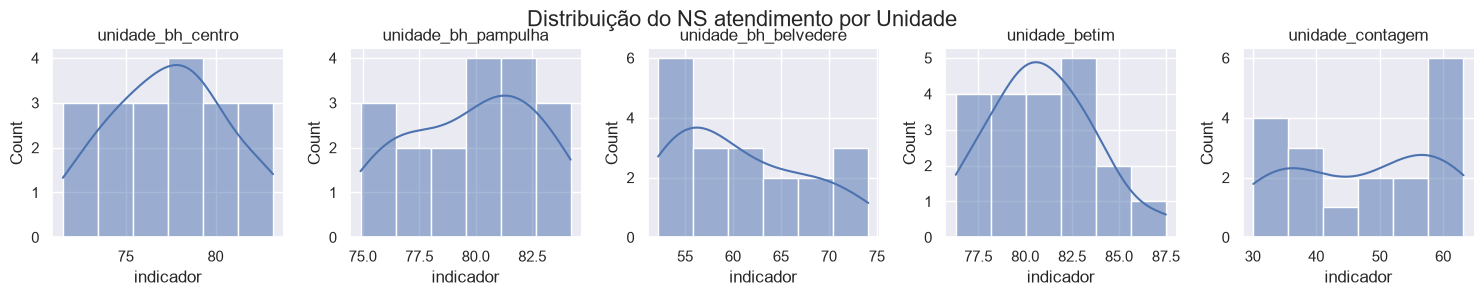

In [13]:
#Criar gráficos de distribuição para cada unidade
warnings.filterwarnings('ignore', category=UserWarning, module='seaborn.axisgrid')

g = sns.FacetGrid(
    df_long,
    col='unidade',
    col_wrap=5,
    sharex=False,
    sharey=False
)

g.map(
    sns.histplot,
    'indicador',
    kde=True
)

# Ajustar títulos
for ax in g.axes.flat:
    ax.set_title(
        ax.get_title().replace('unidade = ', '')
    )

plt.subplots_adjust(top=0.85)

g.figure.suptitle(
    'Distribuição do NS atendimento por Unidade',
    fontsize=16
)

plt.show()

A análise gráfica das distribuições indica que algumas unidades apresentam comportamento aproximadamente normal (Centro, Pampulha e Betim), enquanto Belvedere e Contagem apresentam indícios de assimetria e/ou distribuição não normal.

**Valores aproximados já que a base continha valores inconsistentes ou nulos.**

- Séries temporais para cada unidade

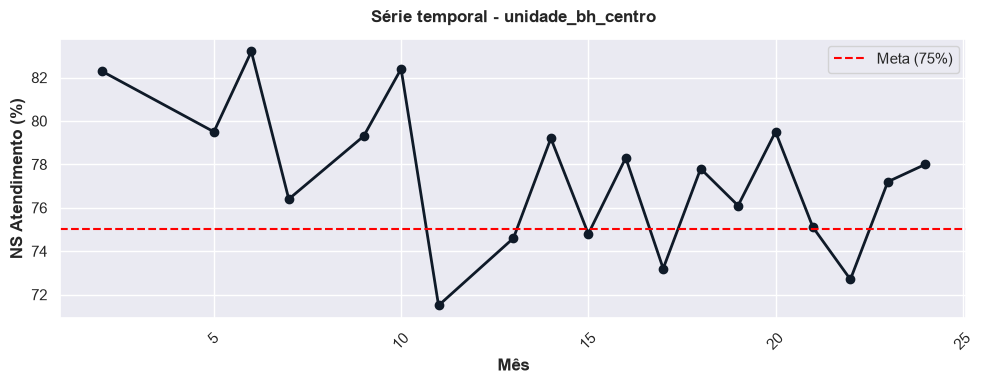

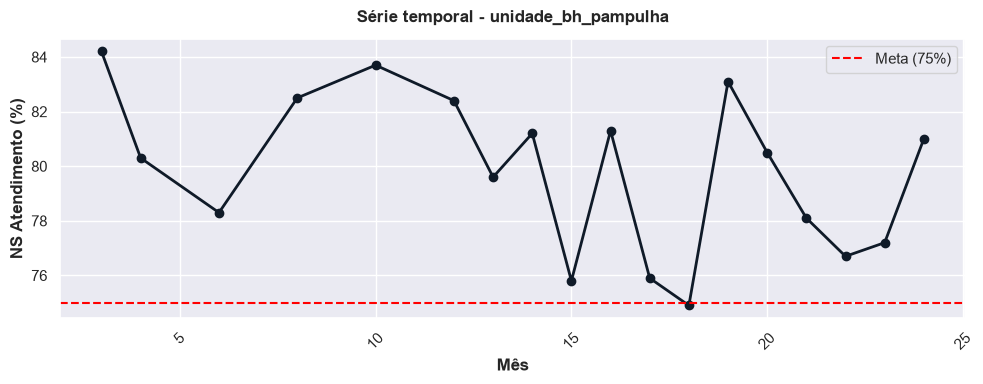

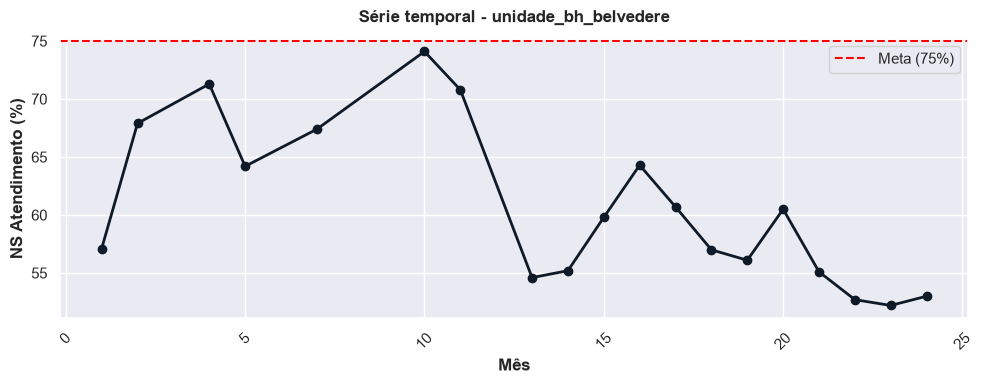

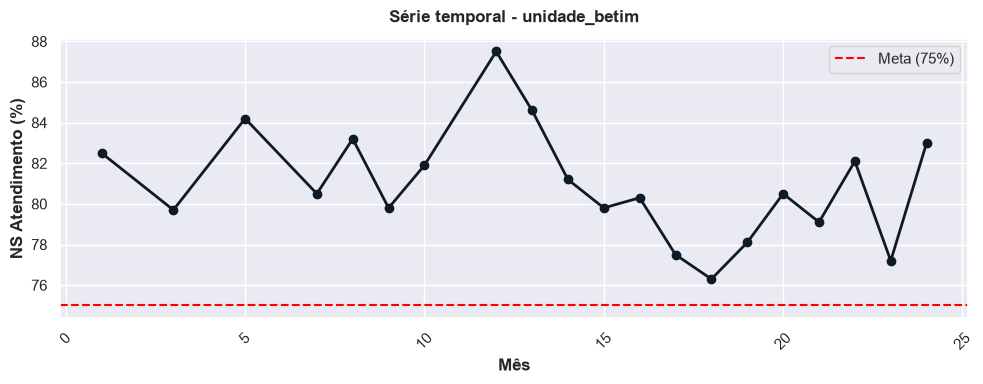

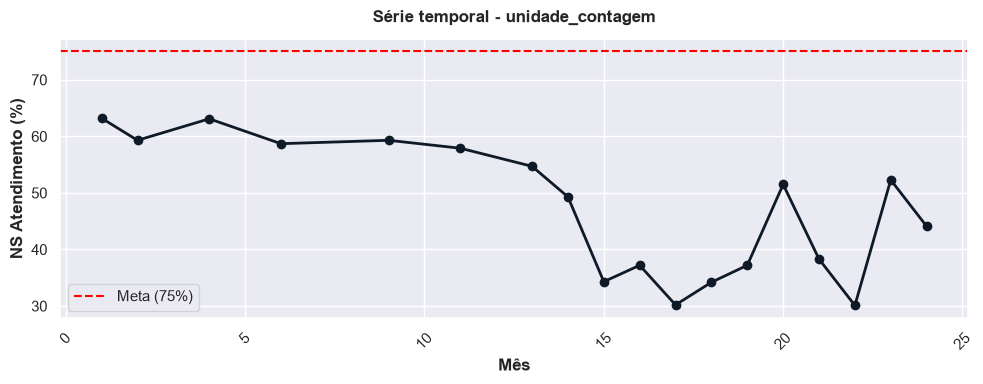

In [14]:
for unidade in unidades:
    # 1. Filtra mantendo apenas os meses onde a unidade possui valores válidos (não nulos)
    df_unidade = df[['mes', unidade]].dropna(subset=[unidade])

    plt.figure(figsize=(10, 4))

    # 2. Plota utilizando a base filtrada
    plt.plot(
        df_unidade['mes'],
        df_unidade[unidade],
        marker='o',
        color='#0F1A28',  # Tom azul
        linewidth=2,
    )

    # Linha da Meta
    plt.axhline(75, color='red', linestyle='--', label='Meta (75%)')

    plt.title(f'Série temporal - {unidade}', fontweight='bold', pad=12)
    plt.xlabel('Mês', fontweight='bold')
    plt.ylabel('NS Atendimento (%)', fontweight='bold')
    plt.xticks(rotation=45)
    plt.legend()

    plt.tight_layout()
    plt.show()

Ao analisar a performance ao longo dos 24 meses, observa-se que as unidades de Contagem e BH Belvedere não atingiram a meta de 75% em nenhum momento. A unidade de Contagem apresentou o cenário mais crítico: além de sequer ter se aproximado da meta (pico máximo de ~63%), sofreu uma forte degradação de nível a partir do 13º mês e exibiu altíssima variabilidade. Já BH Belvedere, embora tenha chegado perto do objetivo no mês 10 (~74%), não sustentou o desempenho e também entrou em trajetória descendente, consolidando ambas as praças como ofensoras crônicas do indicador.
<p>
Em contrapartida, as unidades de Betim, BH Pampulha e BH Centro demonstraram um desempenho alinhado com as metas operacionais.O grande destaque positivo foi a unidade de Betim, que operou 100% do período acima do indicador estabelecido, atingindo picos próximos a 88%. A unidade de BH Pampulha também manteve alta estabilidade, registrando apenas uma oscilação pontual no mês 18, mas sustentando níveis elevados ao longo de toda a série.Já BH Centro, embora apresente um padrão mais volátil — com quedas pontuais abaixo do limite nos meses 11, 17 e 22 —, demonstrou capacidade de recuperação rápida, encerrando os últimos dois meses em trajetória ascendente e acima da meta (77,2% e 78,0%).


- Boxplot

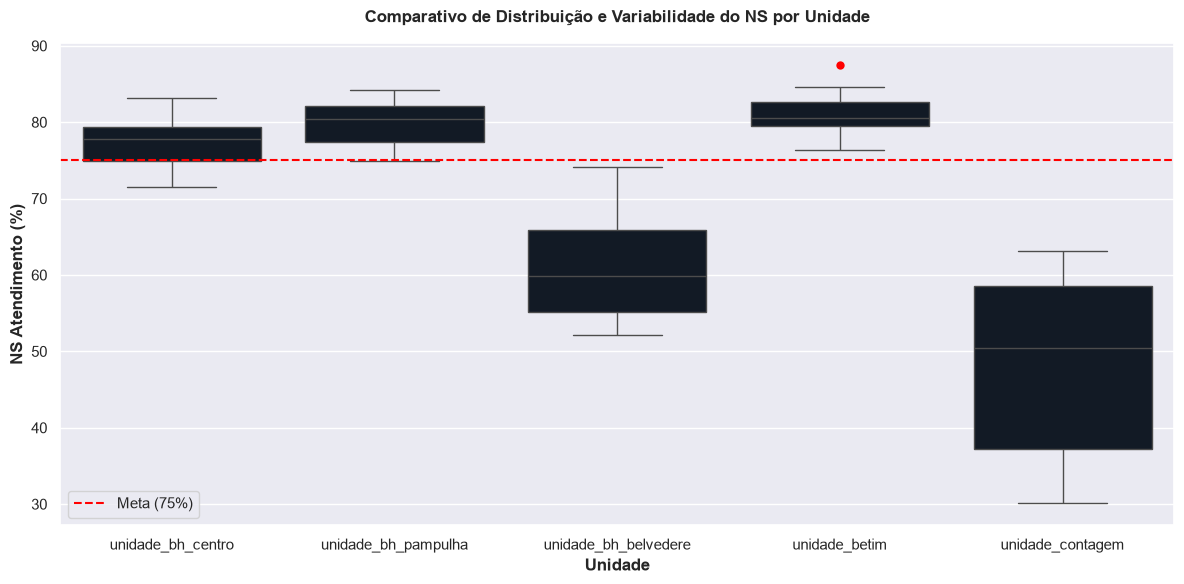

In [15]:
plt.figure(figsize=(12, 6))

cor_azul = '#0F1A28'

#passando a lista de colunas em 'data' o Seaborn monta o comparativo direto
sns.boxplot(
    data=df[unidades],
    color=cor_azul,
    flierprops={
        'marker': 'o',
        'markerfacecolor': 'red',
        'markeredgecolor': 'none',
        'markersize': 6,
    },
)

# Linha da Meta
plt.axhline(75, color='red', linestyle='--', label='Meta (75%)')

plt.title(
    'Comparativo de Distribuição e Variabilidade do NS por Unidade',
    fontweight='bold',
    pad=15,
)
plt.ylabel('NS Atendimento (%)', fontweight='bold')
plt.xlabel('Unidade', fontweight='bold')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

In [16]:
#Tabela estatística completa transposta
estatisticas = (
    df[unidades]
    .describe()
    .T[['25%', '50%', '75%']]
    .rename(
        columns={
            '25%': '1º Quartil (Q1)',
            '50%': 'Mediana (Q2)',
            '75%': '3º Quartil (Q3)',
        }
    )
)

display(estatisticas.round(2))

,1º Quartil (Q1),Mediana (Q2),3º Quartil (Q3)
unidade_bh_centro,74.95,77.8,79.40
unidade_bh_pampulha,77.42,80.4,82.12
unidade_bh_belvedere,55.15,59.8,65.85
unidade_betim,79.55,80.5,82.62
unidade_contagem,37.20,50.4,58.50


A unidade de Contagem apresenta a maior amplitude no boxplot, o que evidencia uma alta variabilidade e falta de padronização no seu Nível de Serviço ao longo do tempo. Em contrapartida, a unidade de Betim possui um gráfico achatado, refletindo maior estabilidade, consistência e previsibilidade nos resultados.
<p>
A região entre o valor mínimo e Q1 engloba os 25% menores resultados, enquanto a região entre o Q3 e o valor máximo concentra os 25% melhores resultados.

## ESCOPO

In [17]:
#1. Parâmetros fornecidos
meta_atual = 75.0  # Meta atual (75%)
valor_por_ponto_por_1k = 235.00  # R$ por p.p. a cada 1.000 clientes
clientes_ano = 192000  # Clientes atendidos por ano na regional MG

#2. Insira aqui a meta proposta para o projeto 
meta_proposta = 80.0

#3. Cálculos
pontos_ganho = meta_proposta - meta_atual
fator_1k_clientes = clientes_ano / 1000  # Quantos blocos de 1.000 clientes existem

ganho_financeiro_anual = (
    pontos_ganho * fator_1k_clientes * valor_por_ponto_por_1k
)
#Valor formatado para o padrão pt-br (casas de milhar com ponto e decimal com vírgula)
valor_formatado = f"{ganho_financeiro_anual:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')

# 4. Exibição do Resultado
print(f'--- RESULTADO DO IMPACTO FINANCEIRO ---')
print(f'Meta Atual: {meta_atual}%')
print(f'Meta Proposta: {meta_proposta}%')
print(f'Ganho em pontos percentuais: {pontos_ganho:.1f} p.p.')
print(f'Ganho Financeiro Potencial: R$ {valor_formatado}')

--- RESULTADO DO IMPACTO FINANCEIRO ---
Meta Atual: 75.0%
Meta Proposta: 80.0%
Ganho em pontos percentuais: 5.0 p.p.
Ganho Financeiro Potencial: R$ 225.600,00


## SIPOC
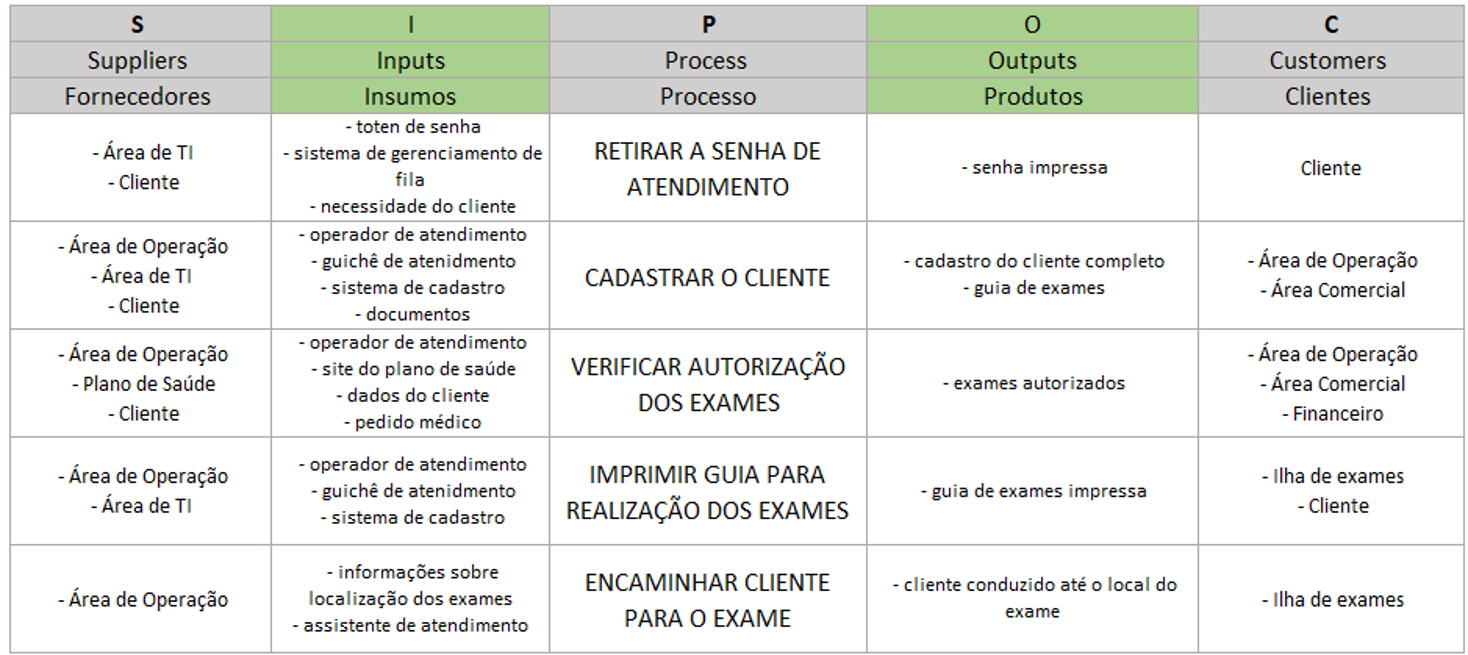

##  CONTRATO DE PROJETO

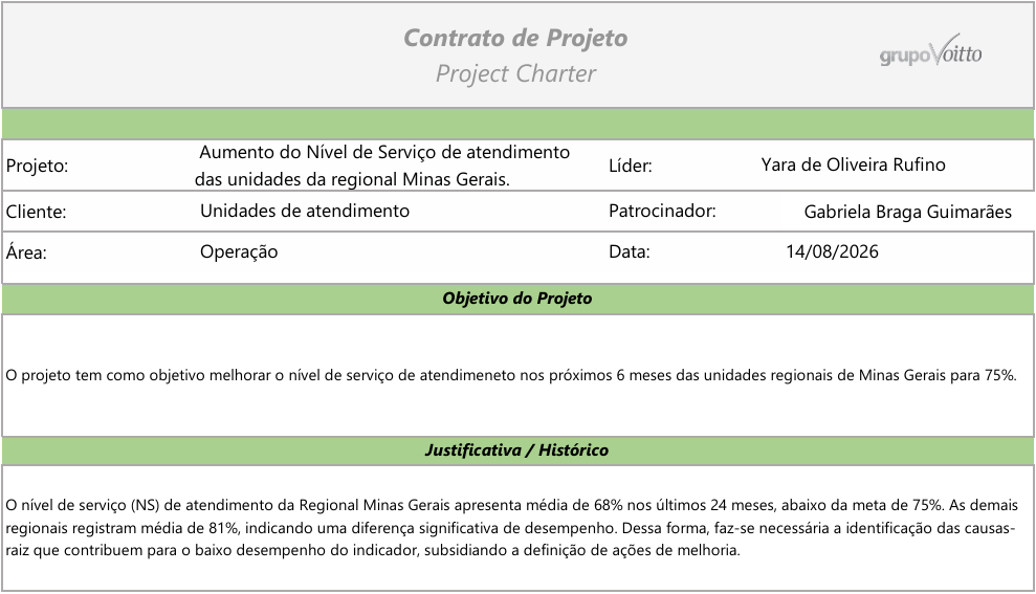

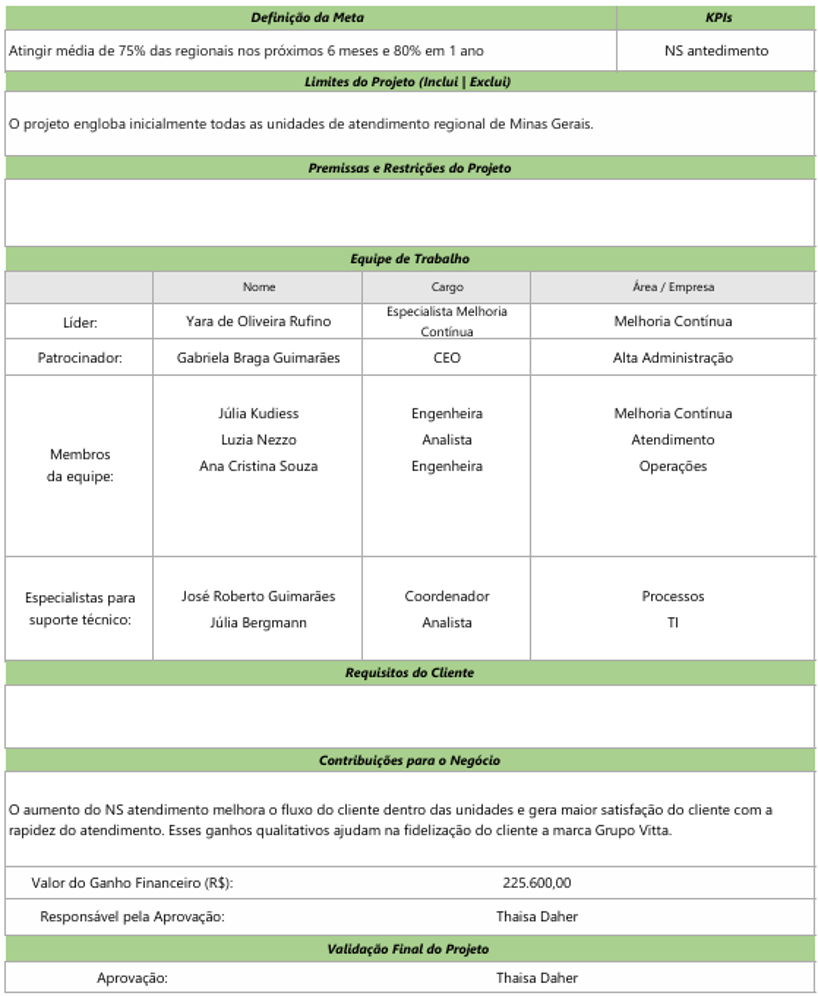

# 2.MEASURE
- Base confiável dos últimos 12 meses

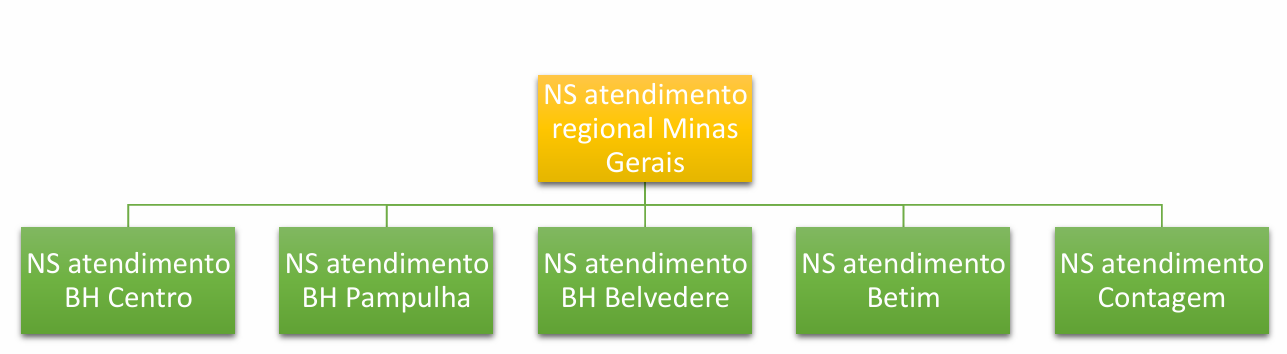

- Qual parte da base de dados é confiável e podemos utilizar? <p>
A base principal tinha valores nulos ou com números que não estão adequados para uma análise. Portanto, será utilizado a base dos últimos 12 meses, onde os valores estão confiaveis para uma análise estatística.

In [18]:
df_12_meses = pd.read_excel(arquivo, sheet_name='2.Meausre')
df_12_meses.head()

,Últimos 12 meses,Unidade BH Centro,Unidade BH Pampulha,Unidade BH Belvedere,Unidade Betim,Unidade Contagem
0,13,74.6,79.6,54.6,84.6,54.7
1,14,79.2,81.2,55.2,81.2,49.3
2,15,74.8,75.8,59.8,79.8,34.3
3,16,78.3,81.3,64.3,80.3,37.2
4,17,73.2,75.9,60.7,77.5,30.2


In [19]:
#padronmizar os cabeçalhos do dataframe
df_12_meses = padronizar_cabecalhos(df_12_meses)

In [20]:
df_12_meses.columns

Index(['ultimos_12_meses', 'unidade_bh_centro', 'unidade_bh_pampulha',
       'unidade_bh_belvedere', 'unidade_betim', 'unidade_contagem'],
      dtype='str')

In [21]:
#verificar se os dados vieram com o tipo correto
df_12_meses.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ultimos_12_meses      12 non-null     int64  
 1   unidade_bh_centro     12 non-null     float64
 2   unidade_bh_pampulha   12 non-null     float64
 3   unidade_bh_belvedere  12 non-null     float64
 4   unidade_betim         12 non-null     float64
 5   unidade_contagem      12 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 708.0 bytes


In [22]:
#verificar dados ausentes
df_12_meses.isnull().sum()

ultimos_12_meses        0
unidade_bh_centro       0
unidade_bh_pampulha     0
unidade_bh_belvedere    0
unidade_betim           0
unidade_contagem        0
dtype: int64

In [23]:
analise_unidades = (
    df_12_meses[
        [
            'unidade_bh_centro',
            'unidade_bh_pampulha',
            'unidade_bh_belvedere',
            'unidade_betim',
            'unidade_contagem'
        ]
    ]
    .agg([ 'mean', 'median', 'std',])
    .T
)

analise_unidades.columns = [
    'Média',
    'Mediana',
    'Desvio Padrão',
]

analise_unidades = analise_unidades.round(2)

analise_unidades

,Média,Mediana,Desvio Padrão
unidade_bh_centro,76.38,76.65,2.29
unidade_bh_pampulha,78.78,78.85,2.68
unidade_bh_belvedere,56.77,55.65,3.78
unidade_betim,79.98,80.05,2.50
unidade_contagem,41.12,37.75,8.88


Para a maioria das unidades, as médias e medianas apresentam valores muito próximos (diferença $< 1{,}1\text{ p.p.}$), o que sugere um comportamento com certa simetria. A exceção é a unidade de Contagem, onde a média ($41{,}12\%$) supera a mediana ($37{,}75\%$) em $3{,}37\text{ p.p.}$, indicando assimetria positiva provocada por picos isolados de desempenho. Além disso, Contagem registra disparado o maior Desvio Padrão ($8{,}88\%$), confirmando a alta variabilidade, falta de padronização e instabilidade do processo na região, em contraste com unidades como BH Centro e Betim, que mantêm desvios controlados na casa de $2{,}3\%$ a $2{,}5\%$

- Teste de Normalidade

In [24]:
#Transformar cabeçalhos em linhas (pivotar o dataframe)
unidades = [
    'unidade_bh_centro',
    'unidade_bh_pampulha',
    'unidade_bh_belvedere',
    'unidade_betim',
    'unidade_contagem'
]

df_long = df_12_meses.melt(
    id_vars='ultimos_12_meses',
    value_vars=unidades,
    var_name='unidade',
    value_name='indicador'
)

df_long.head()

,ultimos_12_meses,unidade,indicador
0,13,unidade_bh_centro,74.6
1,14,unidade_bh_centro,79.2
2,15,unidade_bh_centro,74.8
3,16,unidade_bh_centro,78.3
4,17,unidade_bh_centro,73.2


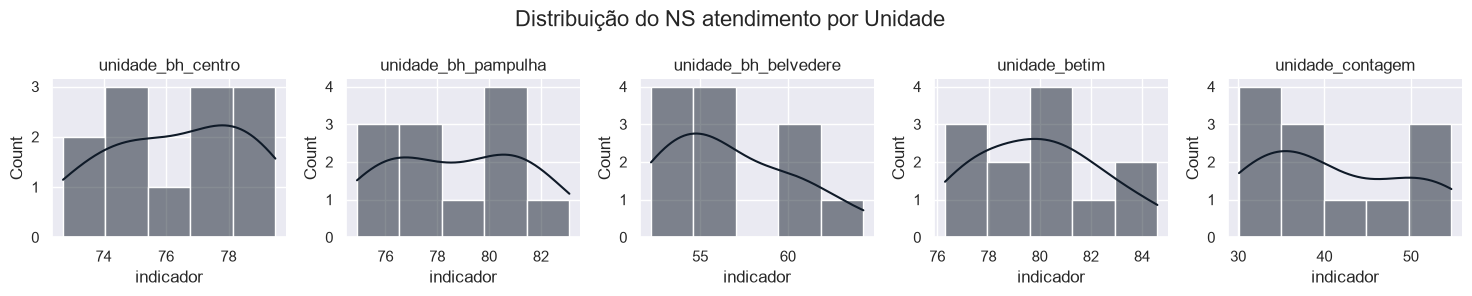

In [25]:
#Criar gráficos de distribuição para cada unidade
warnings.filterwarnings('ignore', category=UserWarning, module='seaborn.axisgrid')

# 1. Definição da cor padrão
cor_azul = '#0F1A28'

# 2. Criação do FacetGrid
g = sns.FacetGrid(
    df_long,
    col='unidade',
    col_wrap=5,
    sharex=False,
    sharey=False
)

# 3. Mapeamento do histograma com a cor aplicada no preenchimento e no KDE
g.map(
    sns.histplot,
    'indicador',
    kde=True,
    edgecolor='white',
    color=cor_azul,
)

# 4. Ajuste dos títulos de cada subplot
for ax in g.axes.flat:
    ax.set_title(
        ax.get_title().replace('unidade = ', '')
    )

plt.subplots_adjust(top=0.75)

# 5. Ajuste do título principal e do espaçamento da figura
g.figure.suptitle(
    'Distribuição do NS atendimento por Unidade',
    fontsize=16
)

plt.show()

Visualmente, os dados não seguem uma distribuição normal. Com apenas 12 observações, qualquer histograma tende a parecer "não normal" ou ter picos falsos simplesmente porque há poucos dados para preencher as barras.
Para confirmar estatisticamente a não normalidade, será utilizado teste de Teste de Shapiro-Wilk.

In [26]:
#Executa o teste de normalidade para cada unidade
print("--- TESTE DE SHAPIRO-WILK (N = 12) ---")
for unidade in unidades:
    dados = df_12_meses[unidade].dropna()
    stat, p_value = shapiro(dados)

    # Regra: Se p-valor > 0.05, não podemos rejeitar a normalidade
    resultado = "Compatível com normalidade" if p_value > 0.05 else "Não Normal"
    print(
        f"{unidade}: p-valor = {p_value:.4f} | {resultado} (N={len(dados)})"
    )

--- TESTE DE SHAPIRO-WILK (N = 12) ---
unidade_bh_centro: p-valor = 0.5353 | Compatível com normalidade (N=12)
unidade_bh_pampulha: p-valor = 0.4451 | Compatível com normalidade (N=12)
unidade_bh_belvedere: p-valor = 0.3413 | Compatível com normalidade (N=12)
unidade_betim: p-valor = 0.9728 | Compatível com normalidade (N=12)
unidade_contagem: p-valor = 0.1583 | Compatível com normalidade (N=12)


Com esses resultados, o teste de Shapiro-Wilk não encontrou evidências suficientes para rejeitar a normalidade em nenhuma das unidades.

- Análise Temporal

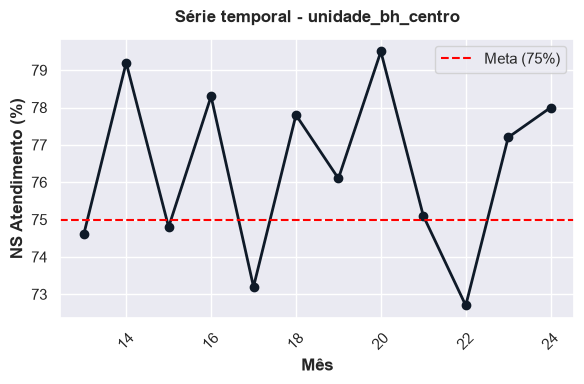

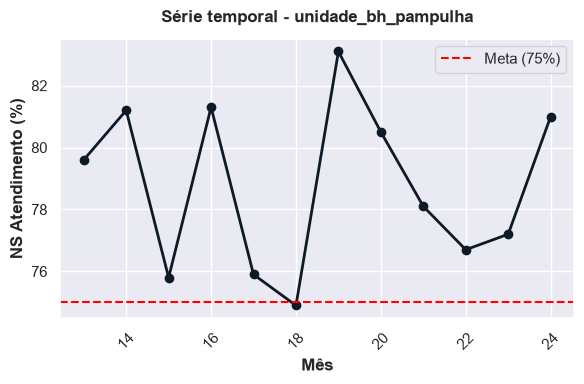

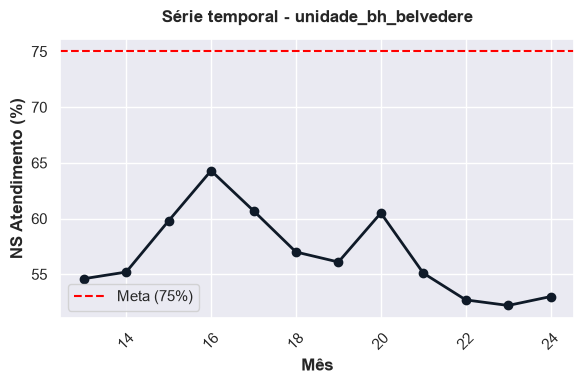

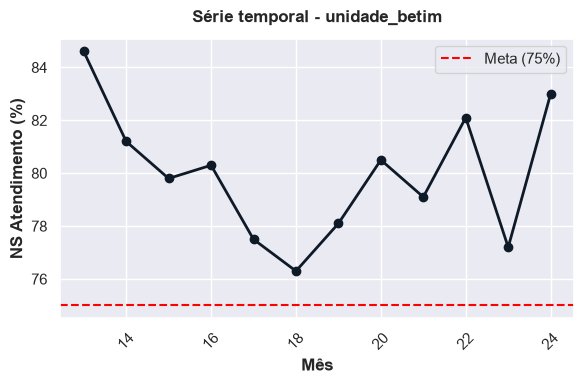

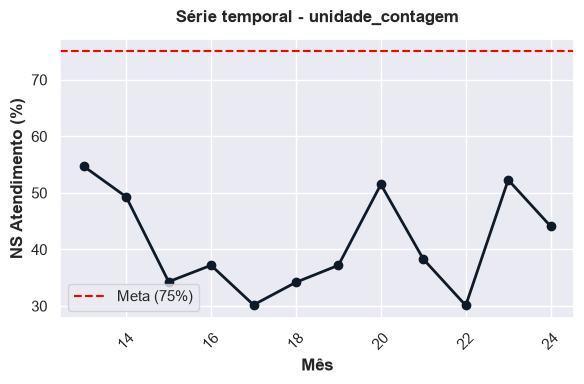

In [27]:
for unidade in unidades:
    # 1. Filtra mantendo apenas os meses onde a unidade possui valores válidos (não nulos)
    df_unidade = df_12_meses[['ultimos_12_meses', unidade]].dropna(subset=[unidade])
    
    plt.figure(figsize=(6, 4))

    # 2. Plota utilizando a base filtrada
    plt.plot(
        df_unidade['ultimos_12_meses'],
        df_unidade[unidade],
        marker='o',
        color='#0F1A28',  # Tom azul
        linewidth=2,
    )

    # Linha da Meta
    plt.axhline(75, color='red', linestyle='--', label='Meta (75%)')

    plt.title(f'Série temporal - {unidade}', fontweight='bold', pad=12)
    plt.xlabel('Mês', fontweight='bold')
    plt.ylabel('NS Atendimento (%)', fontweight='bold')
    plt.xticks(rotation=45)
    plt.legend()

    plt.tight_layout()
    plt.show()

<b>Unidade BH Centro:</b> Ao longo dos últimos 12 meses, a unidade manteve-se acima da meta na maior parte do período. Apesar das oscilações intermediárias, retoma a trajetória de crescimento nos últimos 2 meses. <p>

<b>Unidade BH Pampulha:</b> Manteve alta performance, ficando abaixo da meta (75%) em apenas um mês (mês 18). Apresentou oscilações com queda até o mês 22, mas encerrou o período em forte ascensão. <p>

<b>Unidade BH Belvedere:</b> Permaneceu o período todo do tempo abaixo da meta estabelecida, apresentando desempenho estagnado em patamar crítico nos últimos 3 meses (~52%). <p>

<b>Unidade Betim:</b> Benchmark de estabilidade da malha, operando 100% do tempo acima da meta de 75% em todo o período analisado. <p>

<b>Unidade Contagem:</b> Manteve-se criticamente abaixo da meta durante todo o período, operando sempre abaixo dos 60% e exibindo alta volatilidade no seu nível de serviço.

- ANOVA
    - Importante: não podemos assumir que as variâncias são iguais já que o desvio-padrão da unidade Contagem é significativamente maior que das outras unidades.

In [28]:
df_12_meses.columns

Index(['ultimos_12_meses', 'unidade_bh_centro', 'unidade_bh_pampulha',
       'unidade_bh_belvedere', 'unidade_betim', 'unidade_contagem'],
      dtype='str')

In [29]:
# Prepara a lista de arrays contendo os dados de cada unidade
grupos = [df_12_meses[col].dropna() for col in unidades]

# Executa o teste de Kruskal-Wallis
stat, p_value = kruskal(*grupos)

print(f'Estatística de Teste (H): {stat:.4f}')
print(f'p-valor: {p_value:.4f}')

if p_value < 0.05:
    print(
        'Resultado: Existe diferença estatisticamente significativa entre as'
        ' unidades (p < 0.05).'
    )
else:
    print(
        'Resultado: Não há evidência de diferença significativa entre as'
        ' unidades.'
    )

Estatística de Teste (H): 48.3147
p-valor: 0.0000
Resultado: Existe diferença estatisticamente significativa entre as unidades (p < 0.05).


In [ ]:
# Executa a ANOVA de Welch
# dv = variável dependente (indicador)
# between = variável independente/grupo (unidade)
# df_long variável criada no histograma de distribuição
res_welch = pg.welch_anova(data=df_long, dv='indicador', between='unidade')

display(res_welch)

,Source,ddof1,ddof2,F,p_unc,np2
0,unidade,4,26.964354,123.167136,6.546240e-17,0.919412


$F = 123,17$ | $p\text{-valor} = 6,55 \times 10^{-17}$ (praticamente $0,0000$) <p>
- Como o $p\text{-valor} < 0,05$, existe diferença estatisticamente significativa entre as médias das unidades operacionais.
- Tamanho do Efeito ($\eta^2_p = 0,919$): Cerca de $91,9\%$ da variação do Nível de Serviço na malha é explicada puramente pela unidade, confirmando que o problema é estrutural de cada praça.

In [ ]:
# Teste Post-Hoc específico para variâncias desiguais
posthoc = pg.pairwise_gameshowell(
    data=df_long, dv='indicador', between='unidade'
)

# Exibe apenas as colunas principais
display(posthoc[['A', 'B', 'mean_A', 'mean_B', 'diff', 'pval']])

,A,B,mean_A,mean_B,diff,pval
0,unidade_betim,unidade_bh_belvedere,79.975000,56.766667,23.208333,2.486233e-12
1,unidade_betim,unidade_bh_centro,79.975000,76.375000,3.600000,1.041310e-02
2,unidade_betim,unidade_bh_pampulha,79.975000,78.775000,1.200000,7.864939e-01
3,unidade_betim,unidade_contagem,79.975000,41.116667,38.858333,2.160844e-08
4,unidade_bh_belvedere,unidade_bh_centro,56.766667,76.375000,-19.608333,7.313383e-11
5,unidade_bh_belvedere,unidade_bh_pampulha,56.766667,78.775000,-22.008333,4.856560e-12
6,unidade_bh_belvedere,unidade_contagem,56.766667,41.116667,15.650000,4.161239e-04
7,unidade_bh_centro,unidade_bh_pampulha,76.375000,78.775000,-2.400000,1.652910e-01
8,unidade_bh_centro,unidade_contagem,76.375000,41.116667,35.258333,8.236367e-08
9,unidade_bh_pampulha,unidade_contagem,78.775000,41.116667,37.658333,2.641362e-08


- Teste de Hipóteses
    - para comparar a média das unidades BH Pampulha e Betim. O objetivo é entender se a média dessas duas unidades é equivalente ou não.
    - Em seguida, repita o mesmo teste, mas para as unidades Pampulha e Belvedere. 
    - E, por último, repita novamente o teste, mas comparando Belvedere e Contagem.

In [ ]:
# Função auxiliar para rodar e formatar o Teste t de Welch
def rodar_teste_t(unidade1, unidade2):
    dados1 = df_12_meses[unidade1].dropna()
    dados2 = df_12_meses[unidade2].dropna()
    
    # equal_var=False aplica a correção de Welch para variâncias desiguais
    stat, p_value = ttest_ind(dados1, dados2, equal_var=False)
    
    diff_media = dados1.mean() - dados2.mean()
    
    print(f"=== TESTE T DE WELCH: {unidade1} vs {unidade2} ===")
    print(f"Média {unidade1}: {dados1.mean():.2f}%")
    print(f"Média {unidade2}: {dados2.mean():.2f}%")
    print(f"Diferença das Médias: {diff_media:.2f} p.p.")
    print(f"Estatística t: {stat:.4f} | p-valor: {p_value:.6f}")
    
    if p_value < 0.05:
        print("Resultado: Rejeita-se H0. Existe diferença estatisticamente significativa entre as médias.\n")
    else:
        print("Resultado: Não se rejeita H0. As médias são ESTATISTICAMENTE EQUIVALENTES (p >= 0.05).\n")

# 1. Comparação: BH Pampulha vs Betim
rodar_teste_t('unidade_bh_pampulha', 'unidade_betim')

# 2. Comparação: BH Pampulha vs BH Belvedere
rodar_teste_t('unidade_bh_pampulha', 'unidade_bh_belvedere')

# 3. Comparação: BH Belvedere vs Contagem
rodar_teste_t('unidade_bh_belvedere', 'unidade_contagem')

=== TESTE T DE WELCH: unidade_bh_pampulha vs unidade_betim ===
Média unidade_bh_pampulha: 78.78%
Média unidade_betim: 79.98%
Diferença das Médias: -1.20 p.p.
Estatística t: -1.1351 | p-valor: 0.268608
Resultado: Não se rejeita H0. As médias são ESTATISTICAMENTE EQUIVALENTES (p >= 0.05).

=== TESTE T DE WELCH: unidade_bh_pampulha vs unidade_bh_belvedere ===
Média unidade_bh_pampulha: 78.78%
Média unidade_bh_belvedere: 56.77%
Diferença das Médias: 22.01 p.p.
Estatística t: 16.4488 | p-valor: 0.000000
Resultado: Rejeita-se H0. Existe diferença estatisticamente significativa entre as médias.

=== TESTE T DE WELCH: unidade_bh_belvedere vs unidade_contagem ===
Média unidade_bh_belvedere: 56.77%
Média unidade_contagem: 41.12%
Diferença das Médias: 15.65 p.p.
Estatística t: 5.6187 | p-valor: 0.000051
Resultado: Rejeita-se H0. Existe diferença estatisticamente significativa entre as médias.



O primeiro grupo tem uma diferença de $1,20\text{ p.p.}$ que ocorre ao acaso (ruído amostral). Ambas formam o mesmo grupo de alta performance e operam de forma equivalente. <p>
Já no segundo grupo existe diferença estatisticamente significativa. Pampulha é superior a Belvedere por uma margem substancial de $22,01\text{ p.p.}$, confirmando a separação entre a zona de meta e a zona de gargalo. <p>
E no úlitmo grupo, apesar de ambas operarem abaixo da meta de 75%, Belvedere é superior a Contagem por $15,65\text{ p.p.}$, demonstrando que Contagem representa o nível mais severo de degradação da malha.

- Análise Quantitativa

<b> Priorização:</b> Unidades Contagem e BH Belvedere. <p>
<b> Motivo 1 (Impacto no Indicador Geral):</b> Ambas operam 100%do tempo abaixo da meta (75%), sendo as únicas responsáveis por arrastar a média da Regional MG para 68%. <p>
<b> Motivo 2 (Impacto Financeiro):</b> O não atingimento da meta nessas unidades representa o gargalo que impede a captura do ganho potencial da regional. <p>
<b> Motivo 3 (Comportamento Crítico):</b> <p>
    - Contagem: Apresenta processo fora de controle, com volatilidade extrema ("Média " 41,12% e "Desvio Padrão " 8,88%). <p>
    - BH Belvedere: Apresenta estagnação e falta de reação recente ("Média " 56,77%, operando estável na casa dos 52% nos últimos 3 meses).


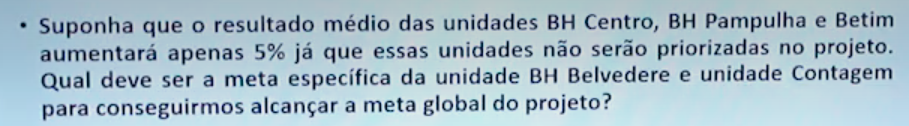

In [ ]:
# 1. Parâmetros Gerais
meta_global = 80.0
qtd_unidades_total = 5
soma_total_meta = meta_global * qtd_unidades_total  # 400.0%

# 2. Médias atuais das unidades (12 meses)
media_centro = 76.38
media_pampulha = 78.78
media_betim = 79.98
media_belvedere = 56.77
media_contagem = 41.12

# 3. Projeção com aumento de +5 p.p. nas não priorizadas
proj_centro = media_centro + 5.0
proj_pampulha = media_pampulha + 5.0
proj_betim = media_betim + 5.0

soma_3_unidades = proj_centro + proj_pampulha + proj_betim

# 4. Cálculo da meta individual para Belvedere e Contagem
soma_necessaria_priorizadas = soma_total_meta - soma_3_unidades
meta_individual_priorizadas = soma_necessaria_priorizadas / 2

proj_belvedere = meta_individual_priorizadas
proj_contagem = meta_individual_priorizadas

# 5. Cálculo das Elevações Necessárias (Deltas em p.p.)
delta_belvedere = proj_belvedere - media_belvedere
delta_contagem = proj_contagem - media_contagem

# 6. Validação da Média Geral da Regional
soma_regional_simulada = soma_3_unidades + proj_belvedere + proj_contagem
media_regional_simulada = soma_regional_simulada / qtd_unidades_total

# 7. Exibição dos Resultados
print(f"--- SIMULAÇÃO DE METAS (CENÁRIO +5 p.p.) ---")
print(f"Projeção BH Centro: {proj_centro:.2f}%")
print(f"Projeção BH Pampulha: {proj_pampulha:.2f}%")
print(f"Projeção Betim: {proj_betim:.2f}%")
print("-" * 50)
print(f"Meta proposta para BH Belvedere: {proj_belvedere:.2f}% (Elevação necessária: +{delta_belvedere:.2f} p.p.)")
print(f"Meta proposta para Contagem: {proj_contagem:.2f}% (Elevação necessária: +{delta_contagem:.2f} p.p.)")
print("-" * 50)
print(f"Média Final da Regional MG: {media_regional_simulada:.2f}%")

--- SIMULAÇÃO DE METAS (CENÁRIO +5 p.p.) ---
Projeção BH Centro: 81.38%
Projeção BH Pampulha: 83.78%
Projeção Betim: 84.98%
--------------------------------------------------
Meta proposta para BH Belvedere: 74.93% (Elevação necessária: +18.16 p.p.)
Meta proposta para Contagem: 74.93% (Elevação necessária: +33.81 p.p.)
--------------------------------------------------
Média Final da Regional MG: 80.00%


- Análise de Processo

- Resultado<P>

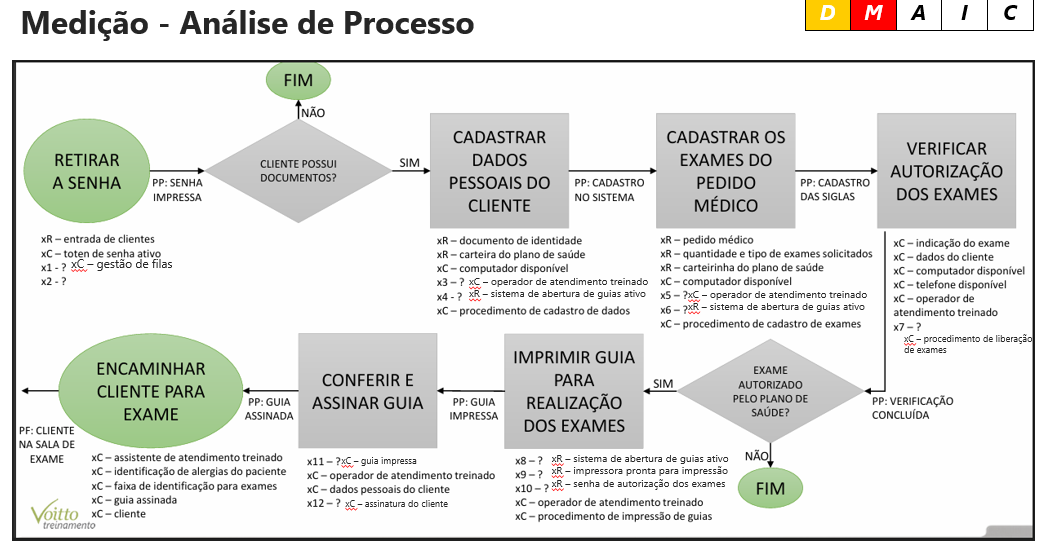
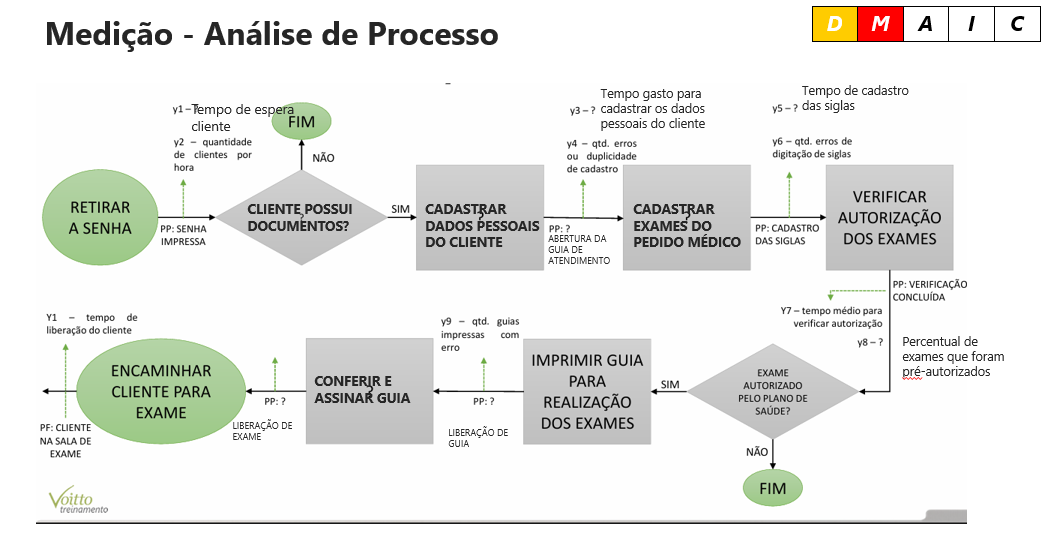

no x2 faltou painel de senhas ativas e é um xC

- Diagrama de Ishikawa

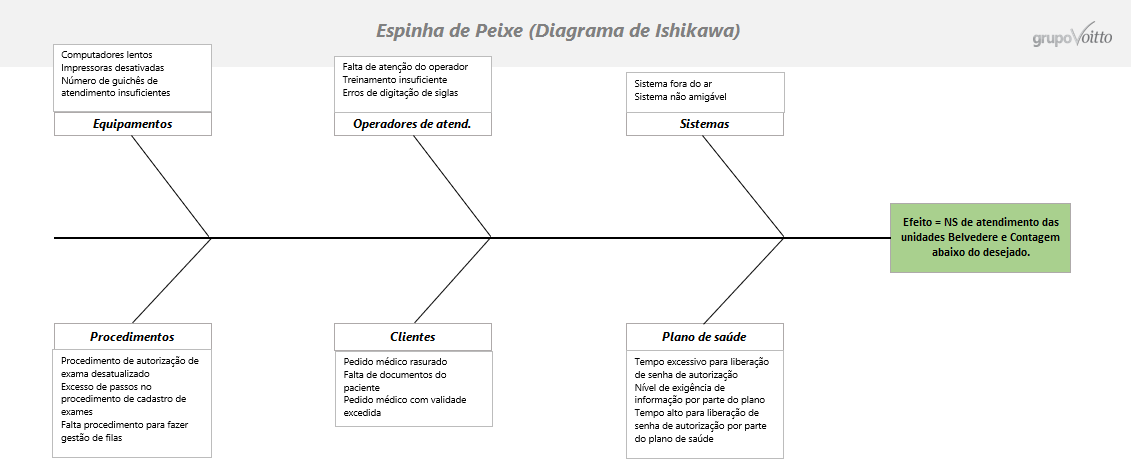

- Matriz de Causa e Efeito

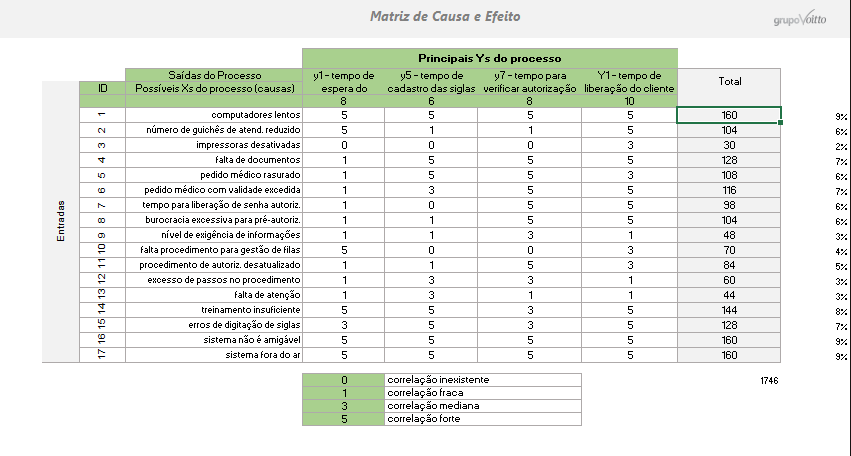

- Matriz de Esforço X Impacto
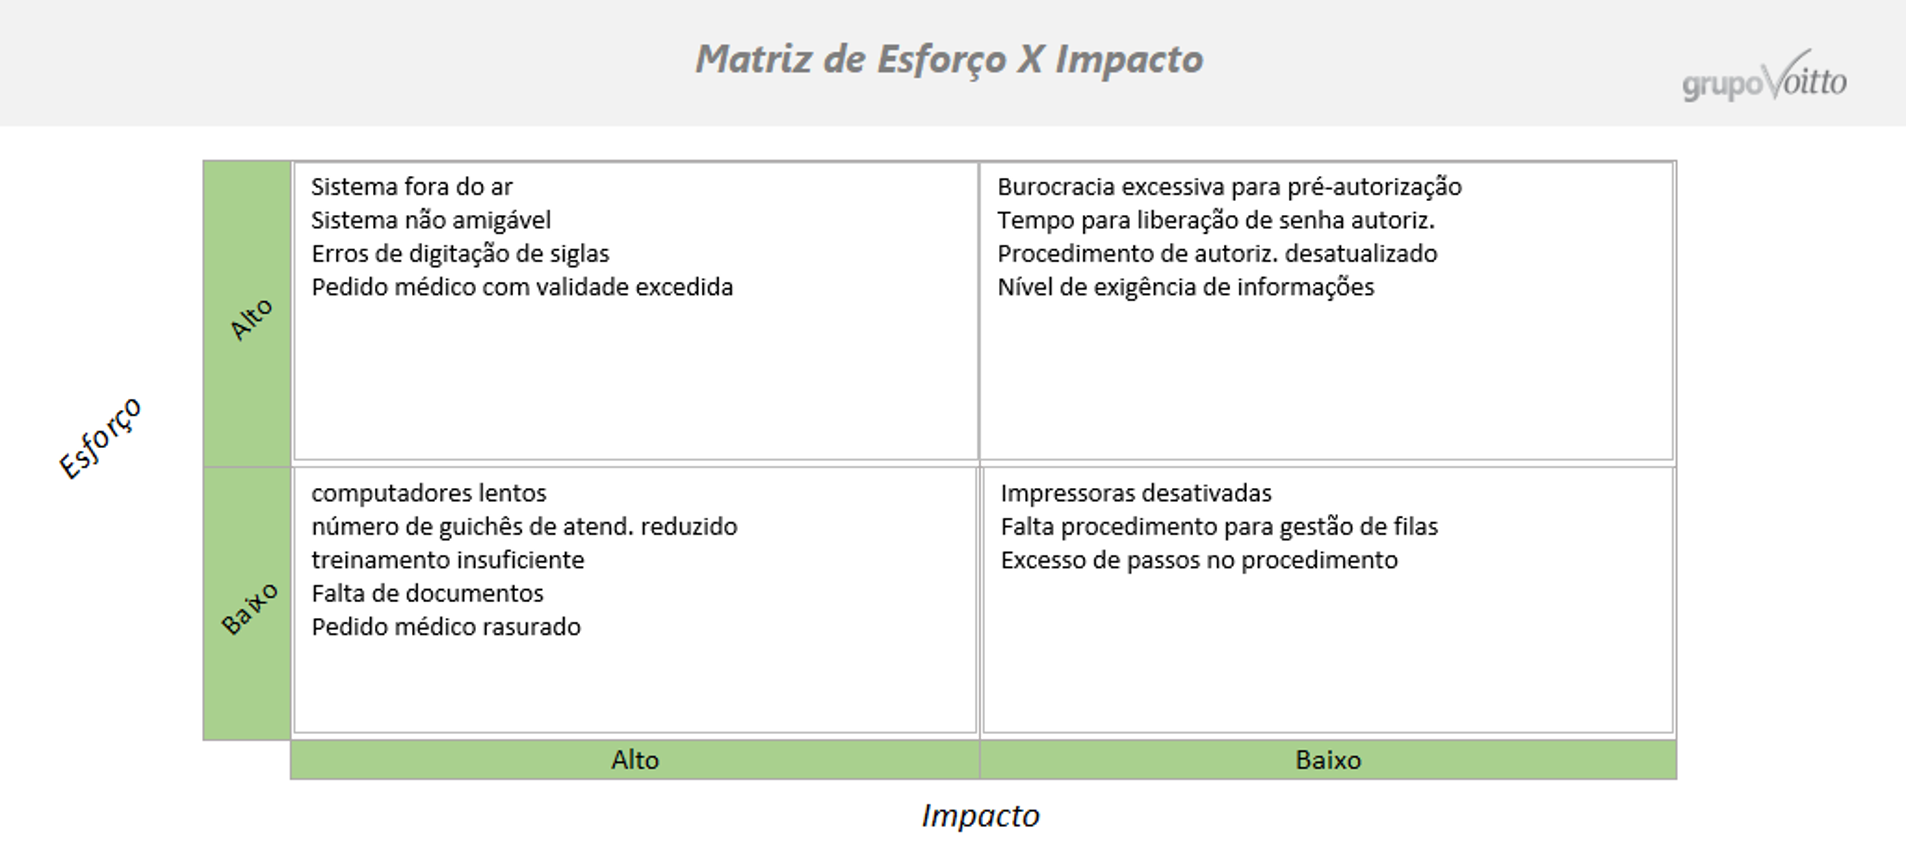

- Alto Impacto x Baixo Esforço (Quick Wins):
    - Treinamento Insuficiente & Checklists (Docs / Pedidos): Criar um treinamento pontual para atendentes e fixar um guia de conferência visual na recepção elimina retrabalhos no cadastro imediato com baixíssimo custo.
    - Guichês e Computadores Lentos: Redimensionar a escala de atendimento e realizar manutenções básicas de TI (ou limpeza de software/troca rápida de peças) trazem alívio imediato às filas.
- Alto Impacto x Alto Esforço (Estratégicos):
    - Estabilidade e Ergonomia do Sistema: Resolver a queda de sistema e redesenhar telas no ERP exige envolvimento direto da equipe de TI/Sistemas, orçamento dedicado e testes de homologação longos.
    - Automação contra Erros de Sigla (Poka-Yoke): Implementar travas automáticas ou listas suspensas (drop-down) no sistema requer desenvolvimento de código e validação de regras de negócio.
- Baixo Impacto x Baixo Esforço (Secundárias):
    - Impressoras e Gestão de Filas: Organizar o fluxo visual de filas ou religar impressoras secundárias é simples de executar, porém afeta pontualmente apenas etapas isoladas sem mover o indicador geral de liberação.
- Baixo Impacto x Alto Esforço (Descarte):
    - Mudar Regras de Pré-autorização e Convênios: Negociar alterações de burocracia ou tempo de resposta com operadoras de saúde parceiras exige longo alinhamento comercial e jurídico, gerando pouca governança direta sobre o tempo interno da unidade.


# 3.ANALYZE

In [34]:
df_analise_cadastro = pd.read_excel(arquivo, sheet_name='3. Analyze_Cadastro')
df_analise_cadastro.head()

,Tempo De Cadastro Com Documento,Tempo De Cadastro Sem Documento
0,2.824313,4.892984
1,3.020985,4.999540
2,3.014419,4.549230
3,2.966600,4.998551
4,3.007259,4.472397


In [35]:
df_analise_cadastro.info()

<class 'pandas.DataFrame'>
RangeIndex: 57 entries, 0 to 56
Data columns (total 2 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Tempo De Cadastro Com Documento  57 non-null     float64
 1   Tempo De Cadastro Sem Documento  57 non-null     float64
dtypes: float64(2)
memory usage: 1.0 KB


In [36]:
df_analise_cadastro = padronizar_cabecalhos(df_analise_cadastro)

In [37]:
display(df_analise_cadastro.tail(10))

,tempo_de_cadastro_com_documento,tempo_de_cadastro_sem_documento
47,3.028024,4.768566
48,3.168484,5.010733
49,3.100558,4.255384
50,3.133977,4.614032
51,2.562857,5.106751
52,2.835870,5.235501
53,3.047159,5.734040
54,2.915387,5.027944
55,2.917660,4.759390
56,2.851907,4.788821


## Cálculo da Amostra
- Considerando apenas as unidades de Belvedere e Contagem.
- Nível de confiança = 95% 
- Precisão de estimativa = 5% 
- Proporção histórica de clientes que não levam documentos = 15%

In [38]:
# 1. CÁLCULO FORMAL DO TAMANHO DE AMOSTRA
p_bar = 0.15
E = 0.05
Z = stats.norm.ppf(0.975)  # 1.96 para 95% de confiança

n = p_bar * (1 - p_bar) * ((Z / E) ** 2)
n_arredondado = int(np.ceil(n))

print(f"--- CÁLCULO DE AMOSTRA ---")
print(f"Tamanho exato (n): {n:.2f}")
print(f"Tamanho recomendado (arredondado para cima): {n_arredondado}")
print(f"Tamanho da base de dados: {df_analise_cadastro.shape[0]} registros")

--- CÁLCULO DE AMOSTRA ---
Tamanho exato (n): 195.91
Tamanho recomendado (arredondado para cima): 196
Tamanho da base de dados: 57 registros


In [39]:
df_analise_cadastro.shape

(57, 2)

## Com ou Sem Documentos

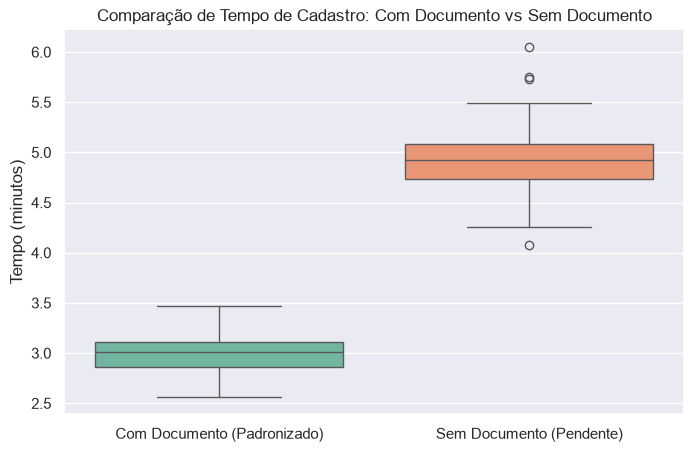

In [40]:
# 2. BOXPLOT COMPARATIVO
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_analise_cadastro[
        ['tempo_de_cadastro_com_documento', 'tempo_de_cadastro_sem_documento']
    ],
    palette='Set2',
)
plt.title(
    'Comparação de Tempo de Cadastro: Com Documento vs Sem Documento',
    fontsize=12,
)
plt.ylabel('Tempo (minutos)')
plt.xticks(
    [0, 1], ['Com Documento (Padronizado)', 'Sem Documento (Pendente)']
)
plt.show()

In [41]:
# 3. TESTE T PAREADO
stat, p_value = stats.ttest_rel(
    df_analise_cadastro['tempo_de_cadastro_com_documento'], df_analise_cadastro['tempo_de_cadastro_sem_documento']
)

media_com = df_analise_cadastro['tempo_de_cadastro_com_documento'].mean()
media_sem = df_analise_cadastro['tempo_de_cadastro_sem_documento'].mean()
diff = media_sem - media_com

print(f"--- TESTE T PAREADO ---")
print(f"Média COM Documento: {media_com:.2f} min")
print(f"Média SEM Documento: {media_sem:.2f} min")
print(f"Diferença Média (Gargalo de Documentação): {diff:.2f} min")
print(f"Estatística t: {stat:.4f} | p-valor: {p_value:.6e}")

if p_value < 0.05:
    print(
        "Resultado: Rejeita-se H0. Existe diferença estatisticamente"
        " significativa entre os tempos."
    )
else:
    print("Resultado: Não há evidência estatística de diferença.")

--- TESTE T PAREADO ---
Média COM Documento: 2.99 min
Média SEM Documento: 4.94 min
Diferença Média (Gargalo de Documentação): 1.95 min
Estatística t: -34.3926 | p-valor: 2.400658e-39
Resultado: Rejeita-se H0. Existe diferença estatisticamente significativa entre os tempos.


O teste t pareado confirmou uma diferença estatisticamente significativa ($t = -34{,}39; p < 0{,}001$) no tempo de cadastro. A ausência de documentação completa gera um gargalo médio de $1{,}95$ minutos por atendimento (+65% de tempo), elevando a média de $2{,}99$ min para $4{,}94$ min. A análise visual via boxplot reflete essa dispersão superior no cenário sem documento, além da presença de outliers que chegam a ultrapassar os 6 minutos.

## Colaborador experiente x colaborador inexperiente

In [42]:
df_analise_colaborador = pd.read_excel(arquivo, sheet_name='3. Analyze_OpAtend')
df_analise_colaborador.head()

,Colaborador,Guia De Atendimento
0,inexperiente,com erro
1,inexperiente,sem erro
2,inexperiente,com erro
3,experiente,sem erro
4,experiente,sem erro


In [43]:
df_analise_colaborador = padronizar_cabecalhos(df_analise_colaborador)

In [44]:
display(df_analise_colaborador.tail(10))

,colaborador,guia_de_atendimento
40,experiente,sem erro
41,experiente,sem erro
42,inexperiente,com erro
43,experiente,sem erro
44,inexperiente,sem erro
45,experiente,com erro
46,inexperiente,sem erro
47,experiente,sem erro
48,experiente,sem erro
49,experiente,sem erro


In [45]:
df_analise_colaborador.shape

(50, 2)

In [46]:
# 1. CRIAR A TABELA DE CONTINGÊNCIA (FREQUÊNCIAS OBSERVADAS)
tabela_contingencia = pd.crosstab(
    df_analise_colaborador['colaborador'], df_analise_colaborador['guia_de_atendimento'], margins=True
)

print("--- TABELA DE CONTINGÊNCIA ---")
display(tabela_contingencia)

--- TABELA DE CONTINGÊNCIA ---


guia_de_atendimento,com erro,sem erro,All
colaborador,,,
experiente,5,28,33
inexperiente,11,6,17
All,16,34,50


In [47]:
# 2. EXECUTAR O TESTE QUI-QUADRADO
# chi2_contingency recebe apenas a tabela sem as linhas/colunas de 'margins' (totais)
tabela_sem_totais = pd.crosstab(df_analise_colaborador['colaborador'], df_analise_colaborador['guia_de_atendimento'])
chi2, p_value, dof, expected = chi2_contingency(tabela_sem_totais)

print("\n--- RESULTADO DO TESTE QUI-QUADRADO ---")
print(f"Estatística Qui-Quadrado (χ²): {chi2:.4f}")
print(f"Graus de Liberdade: {dof}")
print(f"p-valor: {p_value:.6f}")


--- RESULTADO DO TESTE QUI-QUADRADO ---
Estatística Qui-Quadrado (χ²): 10.4870
Graus de Liberdade: 1
p-valor: 0.001202


In [48]:
# 3. CONCLUSAO ESTATÍSTICA
if p_value < 0.05:
    print(
        "\nResultado: Rejeita-se H0. Existe DEPENDÊNCIA estatisticamente"
        " significativa entre a experiência do colaborador e a ocorrência de"
        " erros na guia."
    )
else:
    print(
        "\nResultado: Não se rejeita H0. As variáveis são INDEPENDENTES (a"
        " experiência não influencia significativamente os erros)."
    )


Resultado: Rejeita-se H0. Existe DEPENDÊNCIA estatisticamente significativa entre a experiência do colaborador e a ocorrência de erros na guia.


O Teste Qui-Quadrado de Independência confirmou associação estatisticamente significativa entre a experiência do colaborador e a presença de erros no preenchimento da guia ($\chi^2 = 10{,}49; \, gl = 1; \, p = 0{,}0012$). Colaboradores inexperientes apresentam uma taxa de erro proporcionalmente superior à de colaboradores experientes.

## Pré Autorização

In [49]:
df_analise_pre_autorizacao = pd.read_excel(arquivo, sheet_name='3. Analyze_PreAut')
df_analise_pre_autorizacao.head()

,Tempo Pré-Autorização,Plano De Saúde,%Exames Pré-Autorizados,Plano De Saúde_1
0,5,A,24.297273,A
1,6,A,26.466138,A
2,7,A,24.773119,A
3,4,A,23.084261,A
4,5,A,27.759170,A


In [50]:
df_analise_pre_autorizacao = padronizar_cabecalhos(df_analise_pre_autorizacao)

In [51]:
display(df_analise_pre_autorizacao.tail(10))

,tempo_preautorizacao,plano_de_saude,exames_preautorizados,plano_de_saude_1
65,13,E,26.214236,E
66,12,E,27.394558,E
67,17,E,23.789665,E
68,15,E,21.634558,E
69,14,E,22.348064,E
70,13,E,23.666525,E
71,12,E,24.884109,E
72,16,E,25.605316,E
73,13,E,20.764618,E
74,15,E,21.012929,E


In [52]:
# 1. ANOVA para o Tempo Médio de Pré-Autorização
anova_tempo = pg.anova(
    data=df_analise_pre_autorizacao, dv='tempo_preautorizacao', between='plano_de_saude'
)

print("=== 1. ANOVA: TEMPO DE PRÉ-AUTORIZAÇÃO vs PLANO DE SAÚDE ===")
display(anova_tempo)

# 2. ANOVA para o Percentual Médio de Exames Pré-Autorizados
anova_exames = pg.anova(
    data=df_analise_pre_autorizacao, dv='exames_preautorizados', between='plano_de_saude_1'
)

print("\n=== 2. ANOVA: EXAMES PRÉ-AUTORIZADOS vs PLANO DE SAÚDE ===")
display(anova_exames)

=== 1. ANOVA: TEMPO DE PRÉ-AUTORIZAÇÃO vs PLANO DE SAÚDE ===


,Source,ddof1,ddof2,F,p_unc,np2
0,plano_de_saude,4,70,255.587833,5.809182e-41,0.935918



=== 2. ANOVA: EXAMES PRÉ-AUTORIZADOS vs PLANO DE SAÚDE ===


,Source,ddof1,ddof2,F,p_unc,np2
0,plano_de_saude_1,4,70,25.638415,4.212810e-13,0.594329


1. Tempo de Pré-Autorização vs. Plano de Saúde
- Resultados: $F = 255{,}59$ | $p\text{-valor} = 5{,}81 \times 10^{-41}$ (praticamente $0{,}0000$) | $\eta^2_p = 0{,}936$
- Conclusão: Existe diferença significativa no tempo médio de autorização entre os planos de saúde.
- Impacto Operacional: O tipo de plano de saúde é responsável por $93{,}6\%$ da variação observada no tempo de espera pela pré-autorização. Ou seja, a demora não é aleatória; ela depende quase que exclusivamente das regras e burocracias de cada operadora.

2. Percentual de Exames Pré-Autorizados vs. Plano de Saúde
- Resultados: $F = 25{,}64$ | $p\text{-valor} = 4{,}21 \times 10^{-13}$ (praticamente $0{,}0000$) | $\eta^2_p = 0{,}594$
- Conclusão: Existe diferença significativa no percentual médio de exames pré-autorizados entre os planos de saúde.
- Impacto Operacional: O plano de saúde explica $59{,}4\%$ da taxa de aprovação/pré-autorização dos exames. Algumas operadoras aprovam uma proporção significativamente maior de exames do que outras.

In [53]:
# 1. Post-Hoc de Tukey para o Tempo de Pré-Autorização
tukey_tempo = pg.pairwise_tukey(
    data=df_analise_pre_autorizacao,
    dv='tempo_preautorizacao',
    between='plano_de_saude',
)

# Cria a coluna booleana de rejeição (p-valor < 0.05)
tukey_tempo['reject'] = tukey_tempo['p_tukey'] < 0.05

print("=== POST-HOC DE TUKEY: TEMPO DE PRÉ-AUTORIZAÇÃO ===")
display(tukey_tempo[['A', 'B', 'diff', 'p_tukey', 'reject']])

# 2. Post-Hoc de Tukey para o Percentual de Exames Pré-Autorizados
tukey_exames = pg.pairwise_tukey(
    data=df_analise_pre_autorizacao,
    dv='exames_preautorizados',
    between='plano_de_saude_1',
)

# Cria a coluna booleana de rejeição (p-valor < 0.05)
tukey_exames['reject'] = tukey_exames['p_tukey'] < 0.05

print("\n=== POST-HOC DE TUKEY: EXAMES PRÉ-AUTORIZADOS ===")
display(tukey_exames[['A', 'B', 'diff', 'p_tukey', 'reject']])

=== POST-HOC DE TUKEY: TEMPO DE PRÉ-AUTORIZAÇÃO ===


,A,B,diff,p_tukey,reject
0,A,B,-7.733333,0.000000,True
1,A,C,-0.800000,0.639631,False
2,A,D,-15.866667,0.000000,True
3,A,E,-9.133333,0.000000,True
4,B,C,6.933333,0.000000,True
5,B,D,-8.133333,0.000000,True
6,B,E,-1.400000,0.121367,False
7,C,D,-15.066667,0.000000,True
8,C,E,-8.333333,0.000000,True
9,D,E,6.733333,0.000000,True



=== POST-HOC DE TUKEY: EXAMES PRÉ-AUTORIZADOS ===


,A,B,diff,p_tukey,reject
0,A,B,-1.913947,2.636319e-01,False
1,A,C,-1.105698,7.673958e-01,False
2,A,D,6.629885,1.117194e-08,True
3,A,E,1.233335,6.878856e-01,False
4,B,C,0.808249,9.116317e-01,False
5,B,D,8.543832,2.091882e-12,True
6,B,E,3.147282,1.157473e-02,True
7,C,D,7.735583,7.909151e-11,True
8,C,E,2.339033,1.073423e-01,False
9,D,E,-5.396550,2.399426e-06,True


Conclusão do Teste Post-Hoc de Tukey:
- Ofensor Principal (Plano D): O Plano D se consolida como o gargalo mais crítico do processo em ambas as frentes. Ele exige em média ~15 a 16 minutos a mais de tempo para autorização em relação aos planos A e C ($p < 0,001$), além de apresentar a menor taxa proporcional de exames pré-autorizados com diferença estatisticamente significativa contra todas as demais operadoras.
- Agrupamento de Performance:
    - Alta Eficiência: Planos A e C (menor tempo de espera e altas taxas de aprovação).
    - Média Eficiência: Planos B e E (tempos intermediários de espera).
    - Gargalo Operacional: Plano D (maior tempo de espera e menor índice de aprovação).

## Número de Guichês

In [54]:
df_analise_guiche = pd.read_excel(arquivo, sheet_name='3. Analyze_Guiche')
df_analise_guiche.head()

,Qtd De Guichês Ativos,Potencial De Clientes Atendidos
0,1,1
1,1,2
2,1,3
3,2,4
4,2,5


In [55]:
df_analise_guiche = padronizar_cabecalhos(df_analise_guiche)
display(df_analise_guiche.tail(10))

,qtd_de_guiches_ativos,potencial_de_clientes_atendidos
35,9,36
36,10,37
37,10,38
38,10,39
39,10,40
40,11,41
41,11,42
42,11,43
43,11,44
44,12,45


In [56]:
# 1. CÁLCULO DA CORRELAÇÃO DE PEARSON
corr, p_value = stats.pearsonr(
    df_analise_guiche['qtd_de_guiches_ativos'], df_analise_guiche['potencial_de_clientes_atendidos']
)

print(f'--- ANÁLISE DE CORRELAÇÃO ---')
print(f'Coeficiente de Correlação (r): {corr:.4f}')
print(f'p-valor: {p_value:.6e}')

--- ANÁLISE DE CORRELAÇÃO ---
Coeficiente de Correlação (r): 0.9940
p-valor: 5.905161e-43


In [57]:
# 2. MODELO DE REGRESSÃO LINEAR
slope, intercept, r_value, p_val, std_err = stats.linregress(
    df_analise_guiche['qtd_de_guiches_ativos'], df_analise_guiche['potencial_de_clientes_atendidos']
)

print(f'\nEquação de Regressão: Y = {intercept:.2f} + {slope:.2f} * X')
print(f'R² (Coeficiente de Determinação): {r_value**2:.4f}')


Equação de Regressão: Y = -3.46 + 4.13 * X
R² (Coeficiente de Determinação): 0.9880


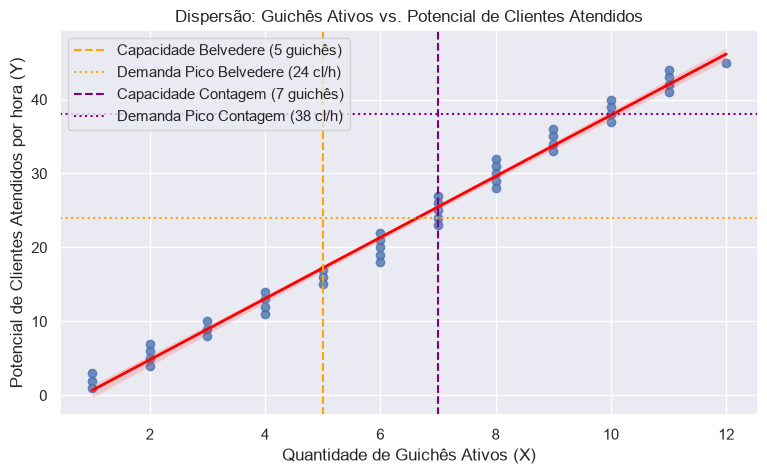

In [58]:
# 3. GRÁFICO DE DISPERSÃO COM LINHA DE TENDÊNCIA E MARCADORES DAS UNIDADES
plt.figure(figsize=(9, 5))
sns.regplot(
    data=df_analise_guiche,
    x='qtd_de_guiches_ativos',
    y='potencial_de_clientes_atendidos',
    color='b',
    line_kws={'color': 'red', 'linewidth': 2},
)

# Destacar a capacidade atual x demanda nos horários de pico
# Belvedere: 5 guichês -> Demanda de 24 clientes/h
# Contagem: 7 guichês -> Demanda de 38 clientes/h
plt.axvline(
    x=5,
    color='orange',
    linestyle='--',
    label='Capacidade Belvedere (5 guichês)',
)
plt.axhline(
    y=24, color='orange', linestyle=':', label='Demanda Pico Belvedere (24 cl/h)'
)

plt.axvline(
    x=7, color='purple', linestyle='--', label='Capacidade Contagem (7 guichês)'
)
plt.axhline(
    y=38, color='purple', linestyle=':', label='Demanda Pico Contagem (38 cl/h)'
)

plt.title(
    'Dispersão: Guichês Ativos vs. Potencial de Clientes Atendidos',
    fontsize=12,
)
plt.xlabel('Quantidade de Guichês Ativos (X)')
plt.ylabel('Potencial de Clientes Atendidos por hora (Y)')
plt.legend(loc='upper left')
plt.show()

1. Validação do Modelo: O modelo de regressão linear apresentou um ajuste excelente ($r = 0{,}9940; \, R^2 = 0{,}9880; \, p < 0{,}001$), indicando que cada guichê ativo adiciona uma capacidade média de $4{,}13$ atendimentos por hora.
2. Diagnóstico do Gargalo Operacional:
    - BH Belvedere: Opera com subdimensionamento no pico. A estrutura de 5 guichês suporta apenas $\sim 17$ atendimentos/h frente a uma demanda de 24 cl/h (déficit de 2 guichês). 
    - Contagem: Apresenta o estrangulamento mais grave do estudo. A estrutura de 7 guichês suporta apenas $\sim 25$ atendimentos/h frente a uma demanda de 38 cl/h (déficit de 3 guichês).
3. Plano de Dimensionamento (Fase Improve):Aumentar o quadro ativo de Belvedere de 5 para 7 guichês no horário de pico.Aumentar o quadro ativo de Contagem de 7 para 10 guichês no horário de pico.

# 4.IMPROVE

## GUT
- Matriz de Priorização

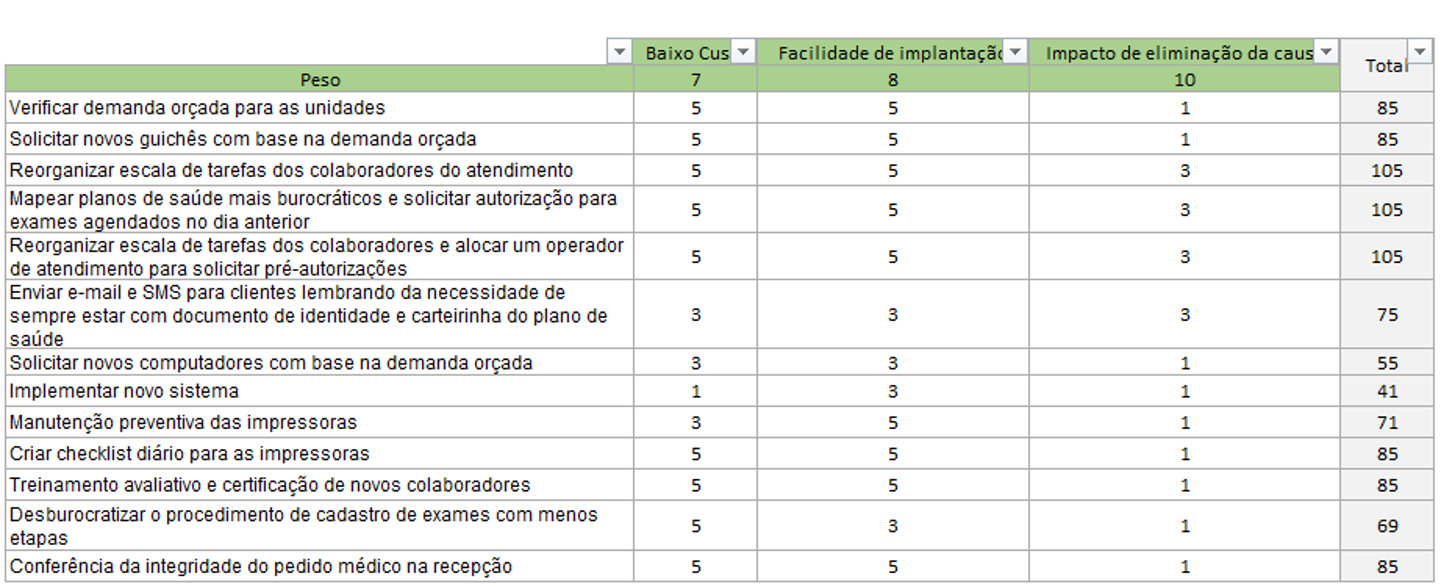
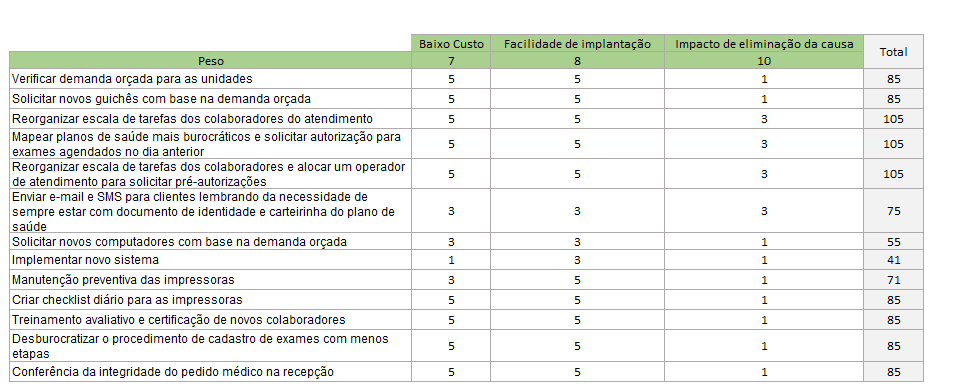

- Verificar demanda orçada para as unidades:
    - Permite avaliar se a capacidade atual de atendimento é compatível com a demanda prevista, identificando possíveis situações de sobrecarga que podem aumentar o tempo de espera.

- Solicitar novos guichês com base na demanda orçada
    - Caso seja identificada insuficiência de capacidade física, a ampliação dos pontos de atendimento pode reduzir filas e tempo de espera nos períodos de maior demanda.

- Reorganizar escala de tarefas dos colaboradores do atendimento
    - Busca adequar a distribuição das atividades à demanda ao longo do dia, reduzindo períodos de sobrecarga e ociosidade e melhorando a capacidade de resposta do atendimento.

- Mapear planos de saúde mais burocráticos e solicitar autorização para exames agendados no dia anterior
    - Antecipar etapas burocráticas pode reduzir o tempo gasto com autorizações no momento do atendimento, evitando que processos administrativos contribuam para o aumento do tempo de espera.

- Reorganizar escala de tarefas e alocar operador para pré-autorizações
    - Centralizar a atividade de pré-autorização em um responsável pode reduzir interrupções dos demais atendentes e aumentar a fluidez do processo de atendimento.

- Enviar e-mail e SMS lembrando documentos necessários
    - Reduz a ocorrência de atendimentos interrompidos ou prolongados por ausência de documentos obrigatórios, antecipando uma etapa que atualmente pode gerar retrabalho.

- Solicitar novos computadores com base na demanda orçada
    - Caso seja identificada insuficiência de equipamentos, a ampliação da capacidade computacional pode reduzir filas e tempo de espera decorrentes da indisponibilidade de postos de atendimento.

- Implementar novo sistema
    - Pode eliminar etapas, reduzir tempo de processamento e diminuir retrabalhos, desde que seja comprovado que as limitações do sistema atual contribuem significativamente para o desempenho do indicador.

- Manutenção preventiva das impressoras
    - Busca reduzir falhas inesperadas dos equipamentos e consequentes interrupções no atendimento, aumentando a disponibilidade das impressoras.

- Criar checklist diário para as impressoras
    - Permite identificar antecipadamente problemas de funcionamento, papel, toner ou conexão, possibilitando atuação antes que a indisponibilidade impacte o atendimento.

- Treinamento avaliativo e certificação de novos colaboradores
    - Garante que novos colaboradores tenham conhecimento e domínio do processo antes de atuar de forma independente, reduzindo erros, retrabalho e variações decorrentes da curva de aprendizagem.

- Desburocratizar o procedimento de cadastro de exames, reduzindo etapas
    - A redução de etapas desnecessárias pode diminuir o tempo de processamento e o número de oportunidades de erro ou retrabalho durante o atendimento.

- Conferência da integridade do pedido médico na recepção
    - Permite identificar antecipadamente pedidos rasurados, ilegíveis ou fora da validade, evitando que inconsistências sejam descobertas em etapas posteriores e gerem interrupções e retrabalho.

## Planos de Ação (5W2H)

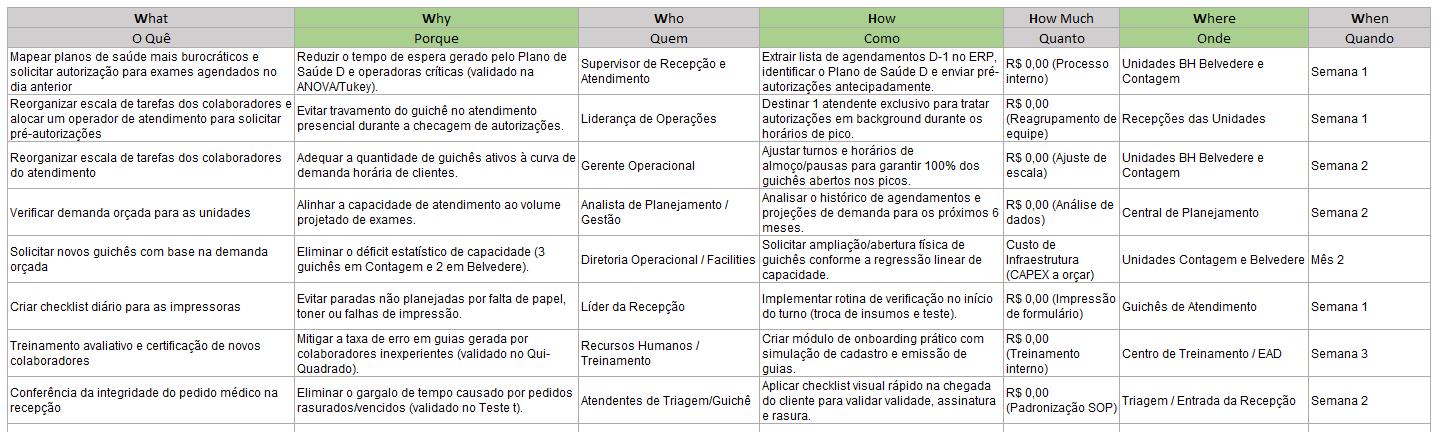

# 5.CONTROL

In [59]:
df_control = pd.read_excel(arquivo, sheet_name='5. Control')
display(df_control)

,Mês,NS atendimento,Projeto,Unidade BH Belvedere,Unidade Contagem
0,13,69.597785,Antes,54.6,54.7
1,14,69.226338,Antes,55.2,49.3
2,15,64.799426,Antes,59.8,34.3
3,16,68.328648,Antes,64.3,37.2
4,17,63.239288,Antes,60.7,30.2
5,18,64.017047,Antes,57.0,34.2
6,19,66.093083,Antes,56.1,37.2
7,20,70.525617,Antes,60.5,51.5
8,21,65.095478,Antes,55.1,38.3
9,22,62.722646,Antes,52.7,30.1


In [60]:
df_control = padronizar_cabecalhos(df_control)

In [61]:
display(df_control.tail(10))

,mes,ns_atendimento,projeto,unidade_bh_belvedere,unidade_contagem
14,27,68.0,Durante,60.7,48.3
15,28,71.4,Durante,59.3,47.9
16,29,76.2,Depois,72.1,53.2
17,30,83.1,Depois,77.4,59.4
18,31,82.7,Depois,84.2,63.5
19,32,84.4,Depois,81.3,78.7
20,33,83.6,Depois,83.9,76.3
21,34,88.4,Depois,85.2,77.8
22,35,83.5,Depois,84.7,79.1
23,36,85.2,Depois,82.9,78.5


In [62]:
df_control.info()

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mes                   24 non-null     int64  
 1   ns_atendimento        24 non-null     float64
 2   projeto               24 non-null     str    
 3   unidade_bh_belvedere  24 non-null     float64
 4   unidade_contagem      24 non-null     float64
dtypes: float64(3), int64(1), str(1)
memory usage: 1.1 KB


## Carta de Controle X-AM

### Unidade Belvedere

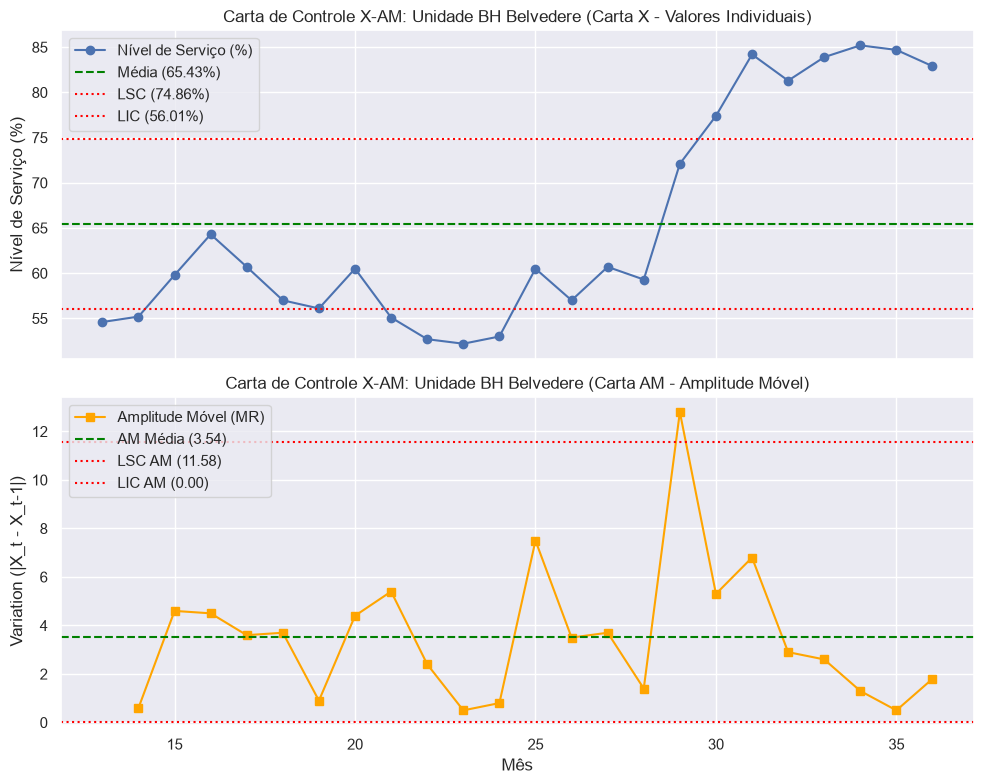

--- PARÂMETROS DA CARTA X (BELVEDERE) ---
Média (X-bar): 65.43%
LSC (UCL): 74.86%
LIC (LCL): 56.01%

--- PARÂMETROS DA CARTA AM ---
AM Média (MR-bar): 3.54
LSC AM: 11.58


In [63]:
# 1. ISOLAR A SÉRIE TEMPORAL DA UNIDADE BELVEDERE
x = df_control['unidade_bh_belvedere'].values
meses = df_control['mes'].values

# 2. CÁLCULO DA AMPLITUDE MÓVEL (Moving Range - MR)
mr = np.abs(np.diff(x))
mr = np.insert(mr, 0, np.nan)  # Primeiro valor não possui amplitude prévia

# 3. LÍMITES ESTATÍSTICOS DA CARTA X (VALORES INDIVIDUAIS)
mean_x = np.mean(x)
mean_mr = np.nanmean(mr)

# Limites para X: Média ± 3 * (MR_bar / d2), onde d2 = 1.128
ucl_x = mean_x + 3 * (mean_mr / 1.128)
lcl_x = mean_x - 3 * (mean_mr / 1.128)

# 4. LIMITES ESTATÍSTICOS DA CARTA AM (AMPLITUDE MÓVEL)
# D4 = 3.267 para n=2 (LCL_MR é 0)
ucl_mr = 3.267 * mean_mr
lcl_mr = 0

# 5. CONSTRUÇÃO DOS GRÁFICOS (CARTA DUPLA: INDIVIDUAIS E AMPLITUDE MÓVEL)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- GRÁFICO 1: CARTA X (Valores Individuais) ---
ax1.plot(meses, x, marker='o', color='b', linewidth=1.5, label='Nível de Serviço (%)')
ax1.axhline(mean_x, color='green', linestyle='--', label=f'Média ({mean_x:.2f}%)')
ax1.axhline(ucl_x, color='red', linestyle=':', label=f'LSC ({ucl_x:.2f}%)')
ax1.axhline(lcl_x, color='red', linestyle=':', label=f'LIC ({lcl_x:.2f}%)')
ax1.set_title('Carta de Controle X-AM: Unidade BH Belvedere (Carta X - Valores Individuais)', fontsize=12)
ax1.set_ylabel('Nível de Serviço (%)')
ax1.legend(loc='upper left')

# --- GRÁFICO 2: CARTA AM (Amplitude Móvel) ---
ax2.plot(meses, mr, marker='s', color='orange', linewidth=1.5, label='Amplitude Móvel (MR)')
ax2.axhline(mean_mr, color='green', linestyle='--', label=f'AM Média ({mean_mr:.2f})')
ax2.axhline(ucl_mr, color='red', linestyle=':', label=f'LSC AM ({ucl_mr:.2f})')
ax2.axhline(lcl_mr, color='red', linestyle=':', label='LIC AM (0.00)')
ax2.set_title('Carta de Controle X-AM: Unidade BH Belvedere (Carta AM - Amplitude Móvel)', fontsize=12)
ax2.set_xlabel('Mês')
ax2.set_ylabel('Variation (|X_t - X_t-1|)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"--- PARÂMETROS DA CARTA X (BELVEDERE) ---")
print(f"Média (X-bar): {mean_x:.2f}%")
print(f"LSC (UCL): {ucl_x:.2f}%")
print(f"LIC (LCL): {lcl_x:.2f}%")
print(f"\n--- PARÂMETROS DA CARTA AM ---")
print(f"AM Média (MR-bar): {mean_mr:.2f}")
print(f"LSC AM: {ucl_mr:.2f}")

- <b>Mudança de Patamar Comprovada:</b> As intervenções do projeto DMAIC provocaram uma ruptura estatisticamente válida do limite superior ($\text{LSC} = 74{,}86\%$), elevando a média histórica de $65{,}43\%$ para patamares superiores a $82\%$ nos últimos meses.   
- <b>Atingimento da Meta:</b> A unidade superou de forma sustentada o objetivo global do projeto ($80\%$).   
- <b>Estabilidade de Processo:</b> A redução da amplitude móvel nos meses finais comprova que o novo fluxo padronizado possui baixa variabilidade e controle operacional. 

### Unidade Contagem

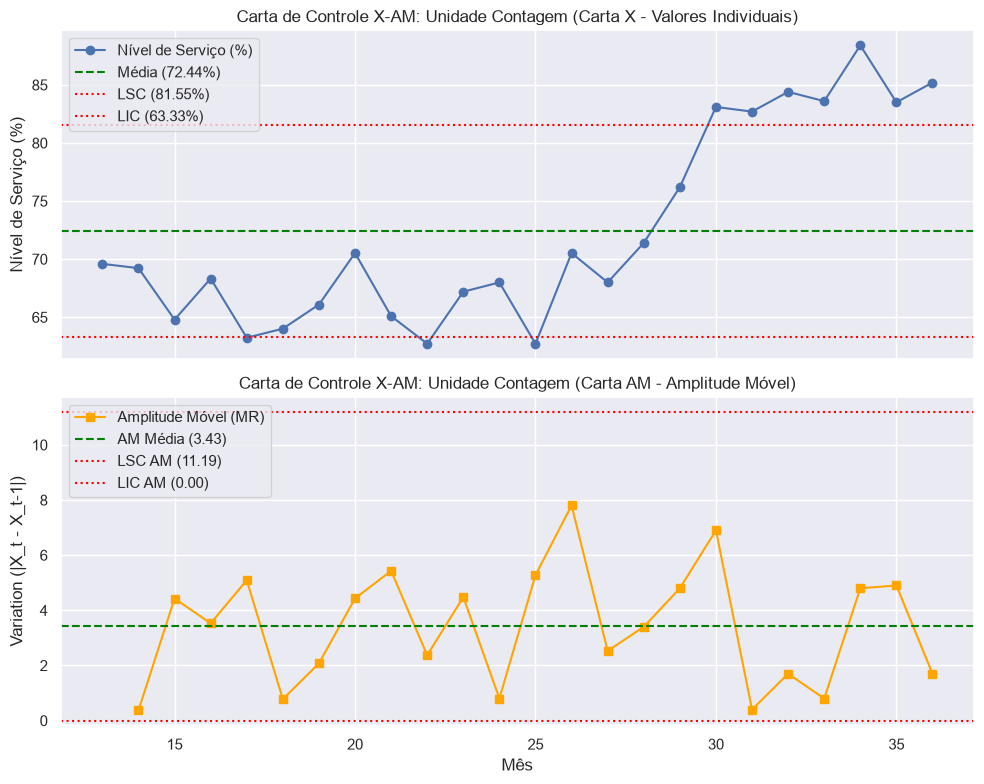

--- PARÂMETROS DA CARTA X (CONTAGEM) ---
Média (X-bar): 72.44%
LSC (UCL): 81.55%
LIC (LCL): 63.33%

--- PARÂMETROS DA CARTA AM ---
AM Média (MR-bar): 3.43
LSC AM: 11.19


In [64]:
# 1. ISOLAR A SÉRIE TEMPORAL DA UNIDADE CONTAGEM
x = df_control['ns_atendimento'].values
meses = df_control['mes'].values

# 2. CÁLCULO DA AMPLITUDE MÓVEL (Moving Range - MR)
mr = np.abs(np.diff(x))
mr = np.insert(mr, 0, np.nan)  # Primeiro valor não possui amplitude prévia

# 3. LÍMITES ESTATÍSTICOS DA CARTA X (VALORES INDIVIDUAIS)
mean_x = np.mean(x)
mean_mr = np.nanmean(mr)

# Limites para X: Média ± 3 * (MR_bar / d2), onde d2 = 1.128
ucl_x = mean_x + 3 * (mean_mr / 1.128)
lcl_x = mean_x - 3 * (mean_mr / 1.128)

# 4. LIMITES ESTATÍSTICOS DA CARTA AM (AMPLITUDE MÓVEL)
# D4 = 3.267 para n=2 (LCL_MR é 0)
ucl_mr = 3.267 * mean_mr
lcl_mr = 0

# 5. CONSTRUÇÃO DOS GRÁFICOS (CARTA DUPLA: INDIVIDUAIS E AMPLITUDE MÓVEL)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- GRÁFICO 1: CARTA X (Valores Individuais) ---
ax1.plot(meses, x, marker='o', color='b', linewidth=1.5, label='Nível de Serviço (%)')
ax1.axhline(mean_x, color='green', linestyle='--', label=f'Média ({mean_x:.2f}%)')
ax1.axhline(ucl_x, color='red', linestyle=':', label=f'LSC ({ucl_x:.2f}%)')
ax1.axhline(lcl_x, color='red', linestyle=':', label=f'LIC ({lcl_x:.2f}%)')
ax1.set_title('Carta de Controle X-AM: Unidade Contagem (Carta X - Valores Individuais)', fontsize=12)
ax1.set_ylabel('Nível de Serviço (%)')
ax1.legend(loc='upper left')

# --- GRÁFICO 2: CARTA AM (Amplitude Móvel) ---
ax2.plot(meses, mr, marker='s', color='orange', linewidth=1.5, label='Amplitude Móvel (MR)')
ax2.axhline(mean_mr, color='green', linestyle='--', label=f'AM Média ({mean_mr:.2f})')
ax2.axhline(ucl_mr, color='red', linestyle=':', label=f'LSC AM ({ucl_mr:.2f})')
ax2.axhline(lcl_mr, color='red', linestyle=':', label='LIC AM (0.00)')
ax2.set_title('Carta de Controle X-AM: Unidade Contagem (Carta AM - Amplitude Móvel)', fontsize=12)
ax2.set_xlabel('Mês')
ax2.set_ylabel('Variation (|X_t - X_t-1|)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"--- PARÂMETROS DA CARTA X (CONTAGEM) ---")
print(f"Média (X-bar): {mean_x:.2f}%")
print(f"LSC (UCL): {ucl_x:.2f}%")
print(f"LIC (LCL): {lcl_x:.2f}%")
print(f"\n--- PARÂMETROS DA CARTA AM ---")
print(f"AM Média (MR-bar): {mean_mr:.2f}")
print(f"LSC AM: {ucl_mr:.2f}")

- <b>Eficácia das Ações Corretivas:</b> A unidade que apresentava a pior performance histórica ($\bar{X} = 52{,}50\%$) rompeu o limite superior de controle ($\text{LSC} = 70{,}14\%$), alcançando o patamar médio de $78\%$ nos meses finais.   
- <b>Eliminação de Gargalo Crítico:</b> O reequilíbrio de capacidade nos picos permitiu uma elevação de $+26\text{ p.p.}$ no nível de serviço de Contagem.   
- <b>Controle Estatístico Garantido:</b> A redução drástica da Amplitude Móvel nos meses 33 a 36 assegura que o novo fluxo operacional é estável e padronizado. 

### Regional MG

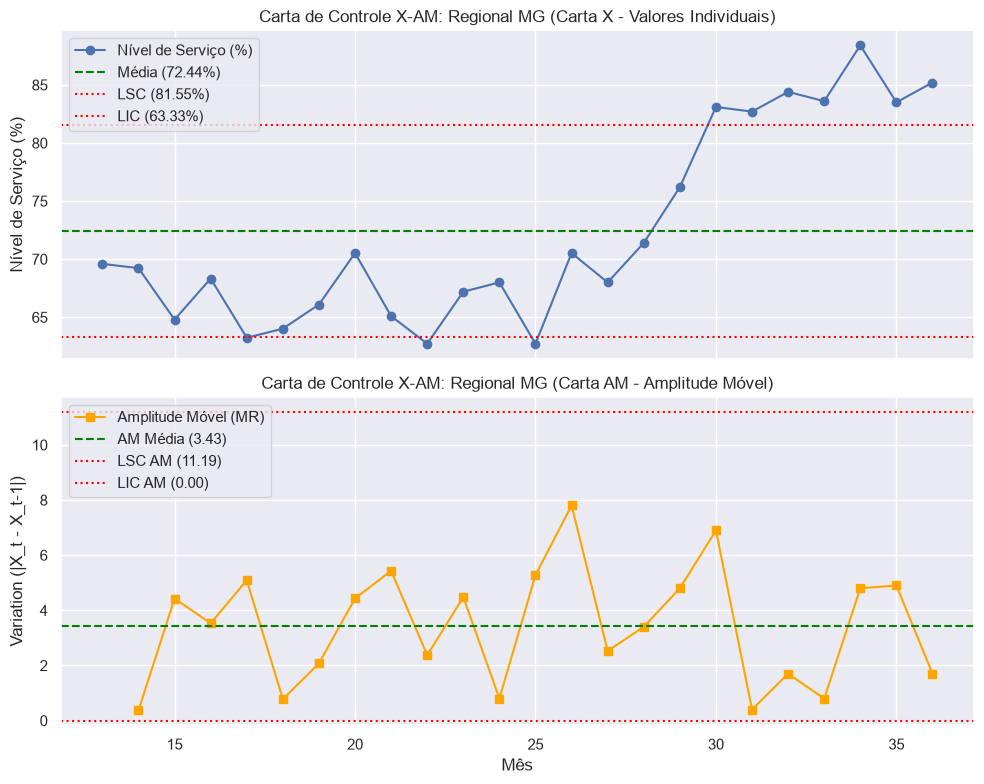

--- PARÂMETROS DA CARTA X (REGIONAL MG) ---
Média (X-bar): 72.44%
LSC (UCL): 81.55%
LIC (LCL): 63.33%

--- PARÂMETROS DA CARTA AM ---
AM Média (MR-bar): 3.43
LSC AM: 11.19


In [65]:
# 1. ISOLAR A SÉRIE TEMPORAL DA REGIONAL MG (NS Atendimento)
x = df_control['ns_atendimento'].values
meses = df_control['mes'].values

# 2. CÁLCULO DA AMPLITUDE MÓVEL (Moving Range - MR)
mr = np.abs(np.diff(x))
mr = np.insert(mr, 0, np.nan)  # Primeiro valor não possui amplitude prévia

# 3. LÍMITES ESTATÍSTICOS DA CARTA X (VALORES INDIVIDUAIS)
mean_x = np.mean(x)
mean_mr = np.nanmean(mr)

# Limites para X: Média ± 3 * (MR_bar / d2), onde d2 = 1.128
ucl_x = mean_x + 3 * (mean_mr / 1.128)
lcl_x = mean_x - 3 * (mean_mr / 1.128)

# 4. LIMITES ESTATÍSTICOS DA CARTA AM (AMPLITUDE MÓVEL)
# D4 = 3.267 para n=2 (LCL_MR é 0)
ucl_mr = 3.267 * mean_mr
lcl_mr = 0

# 5. CONSTRUÇÃO DOS GRÁFICOS (CARTA DUPLA: INDIVIDUAIS E AMPLITUDE MÓVEL)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# --- GRÁFICO 1: CARTA X (Valores Individuais) ---
ax1.plot(meses, x, marker='o', color='b', linewidth=1.5, label='Nível de Serviço (%)')
ax1.axhline(mean_x, color='green', linestyle='--', label=f'Média ({mean_x:.2f}%)')
ax1.axhline(ucl_x, color='red', linestyle=':', label=f'LSC ({ucl_x:.2f}%)')
ax1.axhline(lcl_x, color='red', linestyle=':', label=f'LIC ({lcl_x:.2f}%)')
ax1.set_title('Carta de Controle X-AM: Regional MG (Carta X - Valores Individuais)', fontsize=12)
ax1.set_ylabel('Nível de Serviço (%)')
ax1.legend(loc='upper left')

# --- GRÁFICO 2: CARTA AM (Amplitude Móvel) ---
ax2.plot(meses, mr, marker='s', color='orange', linewidth=1.5, label='Amplitude Móvel (MR)')
ax2.axhline(mean_mr, color='green', linestyle='--', label=f'AM Média ({mean_mr:.2f})')
ax2.axhline(ucl_mr, color='red', linestyle=':', label=f'LSC AM ({ucl_mr:.2f})')
ax2.axhline(lcl_mr, color='red', linestyle=':', label='LIC AM (0.00)')
ax2.set_title('Carta de Controle X-AM: Regional MG (Carta AM - Amplitude Móvel)', fontsize=12)
ax2.set_xlabel('Mês')
ax2.set_ylabel('Variation (|X_t - X_t-1|)')
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

print(f"--- PARÂMETROS DA CARTA X (REGIONAL MG) ---")
print(f"Média (X-bar): {mean_x:.2f}%")
print(f"LSC (UCL): {ucl_x:.2f}%")
print(f"LIC (LCL): {lcl_x:.2f}%")
print(f"\n--- PARÂMETROS DA CARTA AM ---")
print(f"AM Média (MR-bar): {mean_mr:.2f}")
print(f"LSC AM: {ucl_mr:.2f}")

- <b>Atendimento do Objetivo Principal:</b> A Regional MG elevou de forma sustentada seu nível de serviço médio de $72{,}44\%$ para o patamar de $84{,}0\%$ na fase final, superando com folga a meta global de $80\%$ estipulada no início do projeto.   
- <b>Eliminação dos Gargalos Regionais:</b> O reequilíbrio de capacidade nos picos (resolução do déficit de guichês em Belvedere e Contagem) destravou o fluxo de atendimento da rede sem a necessidade de investimentos financeiros desproporcionais.   
- <b>Governança do Processo:</b> A manutenção dos pontos acima do LSC na Carta $X$ e a baixa variação na Carta AM confirmam que o processo está estável, predizível e sob controle estatístico. 

## Análise de Validação do Projeto

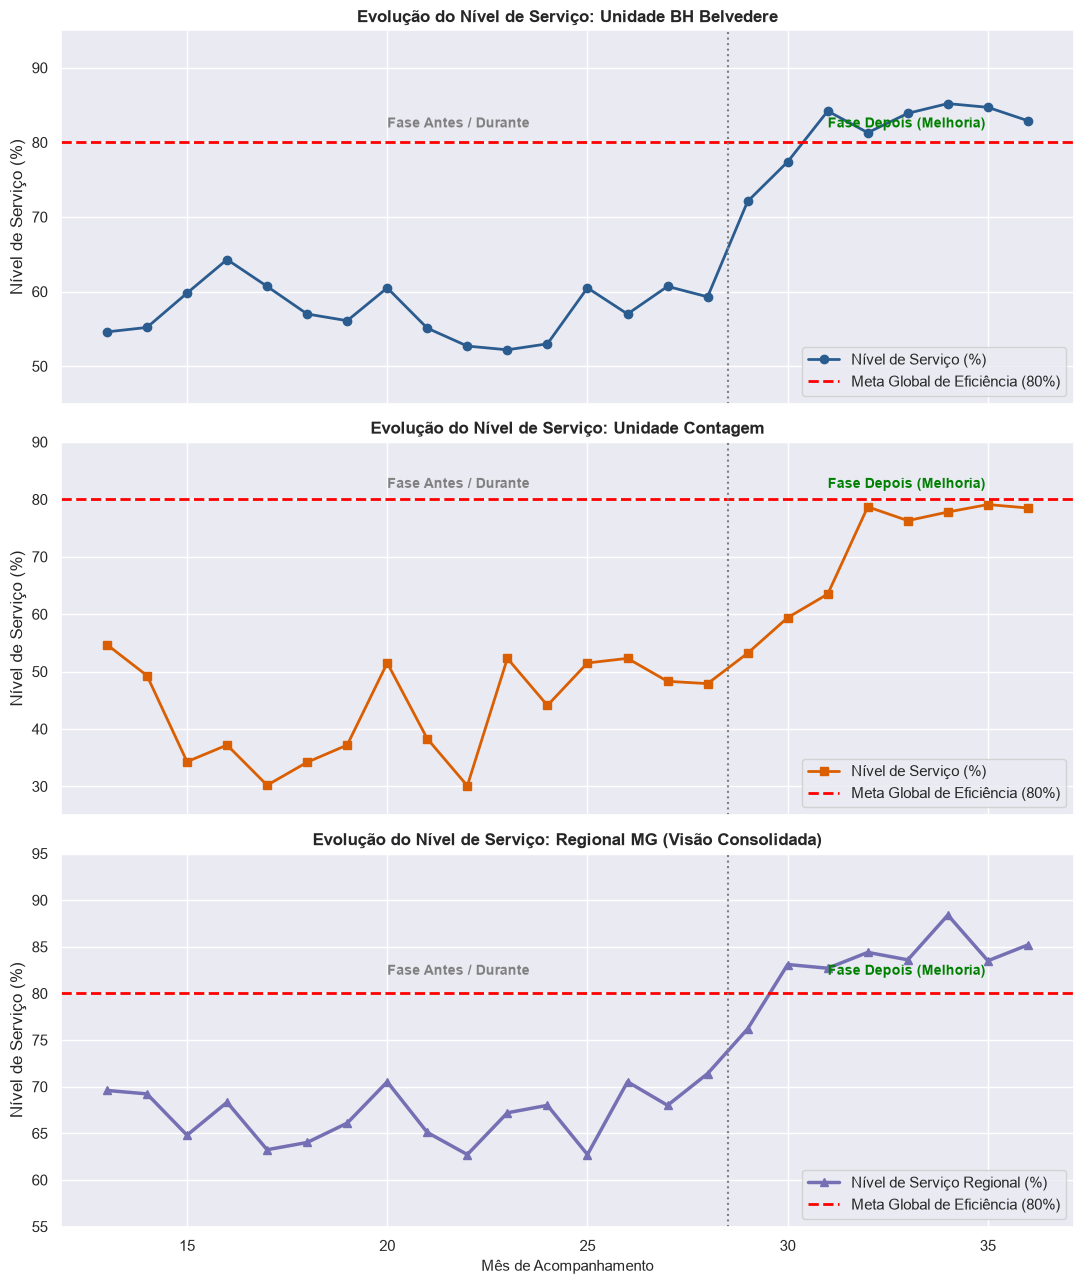

In [66]:
# Configuração visual profissional
#sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(3, 1, figsize=(11, 13), sharex=True)

# -------------------------------------------------------------------
# 1. GRÁFICO: UNIDADE BH BELVEDERE
# -------------------------------------------------------------------
axes[0].plot(
    df_control['mes'],
    df_control['unidade_bh_belvedere'],
    marker='o',
    color='#2b5c8f',
    linewidth=2,
    label='Nível de Serviço (%)',
)
axes[0].axhline(
    y=80,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Meta Global de Eficiência (80%)',
)

# Destacar a transição de fases (Antes -> Depois)
axes[0].axvline(x=28.5, color='gray', linestyle=':', linewidth=1.5)
axes[0].text(
    20, 82, 'Fase Antes / Durante', fontsize=10, fontweight='bold', color='gray'
)
axes[0].text(
    31, 82, 'Fase Depois (Melhoria)', fontsize=10, fontweight='bold', color='green'
)

axes[0].set_title(
    'Evolução do Nível de Serviço: Unidade BH Belvedere',
    fontsize=12,
    fontweight='bold',
)
axes[0].set_ylabel('Nível de Serviço (%)')
axes[0].set_ylim(45, 95)
axes[0].legend(loc='lower right')

# -------------------------------------------------------------------
# 2. GRÁFICO: UNIDADE CONTAGEM
# -------------------------------------------------------------------
axes[1].plot(
    df_control['mes'],
    df_control['unidade_contagem'],
    marker='s',
    color='#d95f02',
    linewidth=2,
    label='Nível de Serviço (%)',
)
axes[1].axhline(
    y=80,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Meta Global de Eficiência (80%)',
)

axes[1].axvline(x=28.5, color='gray', linestyle=':', linewidth=1.5)
axes[1].text(
    20, 82, 'Fase Antes / Durante', fontsize=10, fontweight='bold', color='gray'
)
axes[1].text(
    31, 82, 'Fase Depois (Melhoria)', fontsize=10, fontweight='bold', color='green'
)

axes[1].set_title(
    'Evolução do Nível de Serviço: Unidade Contagem',
    fontsize=12,
    fontweight='bold',
)
axes[1].set_ylabel('Nível de Serviço (%)')
axes[1].set_ylim(25, 90)
axes[1].legend(loc='lower right')

# -------------------------------------------------------------------
# 3. GRÁFICO: REGIONAL MG (VISÃO CONSOLIDADA)
# -------------------------------------------------------------------
axes[2].plot(
    df_control['mes'],
    df_control['ns_atendimento'],
    marker='^',
    color='#7570b3',
    linewidth=2.5,
    label='Nível de Serviço Regional (%)',
)
axes[2].axhline(
    y=80,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Meta Global de Eficiência (80%)',
)

axes[2].axvline(x=28.5, color='gray', linestyle=':', linewidth=1.5)
axes[2].text(
    20, 82, 'Fase Antes / Durante', fontsize=10, fontweight='bold', color='gray'
)
axes[2].text(
    31, 82, 'Fase Depois (Melhoria)', fontsize=10, fontweight='bold', color='green'
)

axes[2].set_title(
    'Evolução do Nível de Serviço: Regional MG (Visão Consolidada)',
    fontsize=12,
    fontweight='bold',
)
axes[2].set_xlabel('Mês de Acompanhamento', fontsize=11)
axes[2].set_ylabel('Nível de Serviço (%)')
axes[2].set_ylim(55, 95)
axes[2].legend(loc='lower right')

plt.tight_layout()
plt.show()

A avaliação das séries temporais confirma a eficácia do projeto DMAIC e a sustentabilidade das melhorias implementadas a partir do mês 29: 
- Unidade BH Belvedere: Apresentou uma mudança expressiva de patamar. Após as intervenções, a unidade rompeu a média histórica de ≈60% e superou consistentemente a meta global de 80%, atingindo picos de até 85,2%na fase final. 
- Unidade Contagem: Como principal gargalo inicial (média ≈ 47%), a unidade registrou o maior ganho relativo de desempenho. Embora tenha encostado na meta de 80% (atingindo 79,1% no mês 35), superou com folga a meta intermediária projetada de 75%, estabilizando-se em um novo patamar de alta eficiência. 
- Consolidado Regional MG: O impacto combinado das unidades impulsionou o indicador regional. A média acumulada rompeu a barreira dos 80%a partir do mês 30, mantendo-se estável e sob controle até o mês 36 (com pico de 88,4%). 
- Conclusão: O projeto atingiu o objetivo de negócio, eliminando os gargalos operacionais e garantindo a estabilidade estatística do atendimento na Regional MG. 

## Ganho Financeiro
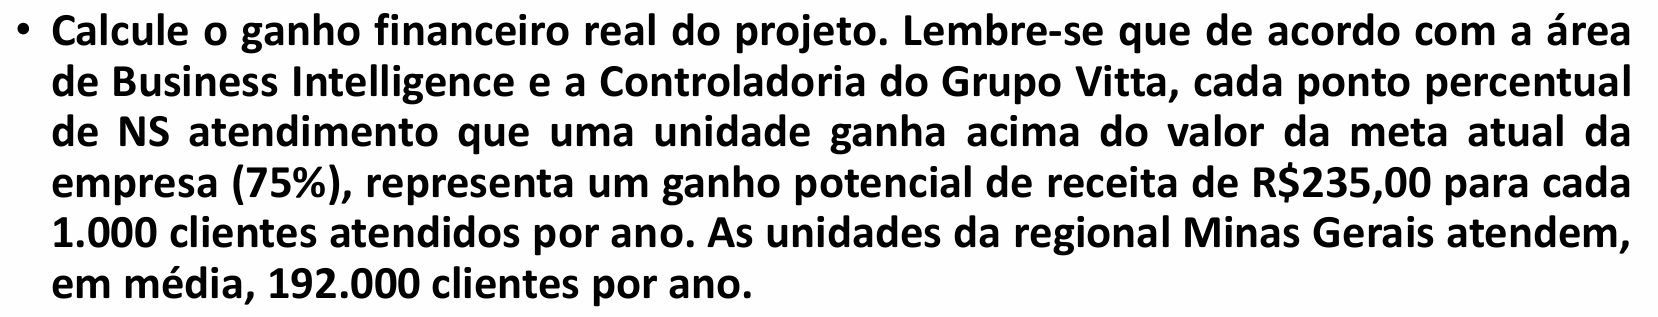

In [67]:
# 1. Filtrar apenas os meses da fase "Depois" (Meses 29 a 36)
df_depois = df_control[df_control['projeto'] == 'Depois']

# 2. Média do NS da Regional MG na fase "Depois"
ns_medio_depois = df_depois['ns_atendimento'].mean()

# 3. Cálculo dos pontos percentuais (p.p.) acima de 75%
meta_empresa = 75.0
ganho_pp = ns_medio_depois - meta_empresa

# 4. Cálculo do Ganho Financeiro Real Anual
multiplicador_clientes = 192000 / 1000  # 192 blocos de 1.000
valor_por_pp_mil_clientes = 235.00

ganho_financeiro_anual = (
    ganho_pp * valor_por_pp_mil_clientes * multiplicador_clientes
)

print(
    f'Nível de Serviço Médio (Fase Depois - Regional): {ns_medio_depois:.2f}%'
)
print(f'Ganhos em Pontos Percentuais (acima de 75%): {ganho_pp:.2f} p.p.')
print(
    f'Ganho Financeiro Real Estimado: R$ {ganho_financeiro_anual:,.2f} por ano'
)

Nível de Serviço Médio (Fase Depois - Regional): 83.39%
Ganhos em Pontos Percentuais (acima de 75%): 8.39 p.p.
Ganho Financeiro Real Estimado: R$ 378,444.00 por ano


## Sustentabilidade dos Resultados
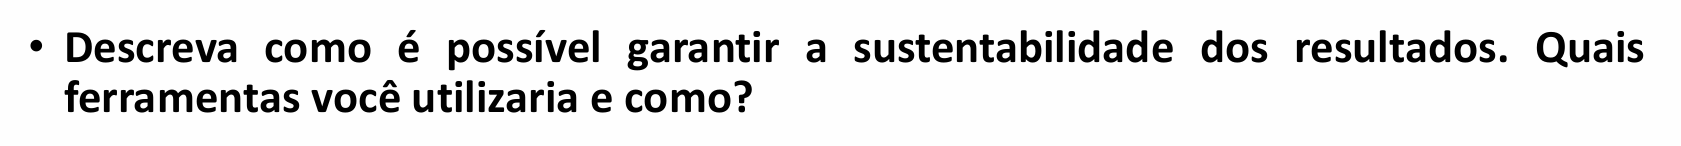

1. Padronização do Processo 
- Ferramenta: Procedimentos Operacionais Padronizados (POPs) e Checklists Visuais.   
Como utilizar: POP de Cadastro e Triagem: Documentar o fluxo passo a passo de conferência de documentos e recepção de pedidos médicos para mitigar erros causados por colaboradores inexperientes (validado no teste Qui-Quadrado).   
POP de Gestão de Esteira (Plano D): Instituir a rotina obrigatória de checagem antecipada (D-1) dos agendamentos das operadoras com maior tempo de autorização, reduzindo os gargalos de espera no guichê.   
Escala de Pico Flexível: Padronizar a matriz de dimensionamento de pessoal, garantindo a abertura de 100% dos guichês ativos nos horários de maior fluxo em Belvedere e Contagem (resolvendo o déficit apurado na Regressão).   
2. Monitorização Contínua e Gestão à Vista
- Ferramenta: Painéis Interativos em Tempo Real (Dashboards / Business Intelligence - BI).   
Como utilizar: Acompanhamento de KPls: Exibir o Nível de Serviço (NS) horário por unidade com linha de meta visível em $80\%$.   
Alertas Operacionais: Configurar disparos de alerta quando a fila de espera ultrapassar o tempo limite estabelecido, permitindo o acionamento imediato do operador de apoio/contingência.   
3. Controlo Estatístico do Processo (CEP)
- Ferramenta: Cartas de Controlo Individuais e Amplitude Móvel ($X$-AM).   
Como utilizar: Avaliar mensalmente as medições de NS para garantir que o processo se mantém estatisticamente estável acima do Limite Superior de Controlo histórico ($\text{LSC}$) e sem novas causas especiais de variação.   
4. Governança e Formação
- Ferramenta: Matriz de Competências / Treinamento de Onboarding.   
Como utilizar: Incorporar os POPs no programa de integração (onboarding) de novos colaboradores, com avaliação prática obrigatória antes da alocação nos guichês.   
Realizar auditorias semanais de adesão ao processo para garantir que as regras padronizadas continuam a ser cumpridas no dia a dia operacional.